In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import os
import matplotlib as mpl
import matplotlib.font_manager as fm
from scipy import stats

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df= pd.read_csv(r'/Users/gggyyu/Desktop/(아이엠뱅크) 2025 교육용 데이터/(아이엠뱅크) 2025 교육용 데이터.csv', encoding='cp949')
df_b = pd.read_csv(r"/Users/gggyyu/im_bank/project_1/iM뱅크_금리현황_2022-2024.csv")
fee_df = pd.read_csv(r'/Users/gggyyu/im_bank/project_1/추정비이자수익률.csv')

#df_c = pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\iM뱅크_금리현황_2022-2024(post).csv')

In [4]:
font_file_candidates = [
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',
    '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
]
selected_font_file = next((font for font in font_file_candidates if os.path.exists(font)), None)
font_name = None
if selected_font_file is not None:
    try:
        fm.fontManager.addfont(selected_font_file)
    except Exception:
        pass
    font_name = fm.FontProperties(fname=selected_font_file).get_name()
    print(f'사용 폰트 파일: {selected_font_file}')
    print(f'적용 폰트 이름: {font_name}')
else:
    print('사용 가능한 한글 폰트 파일을 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')

# seaborn보다 먼저 matplotlib 기본 폰트를 고정합니다.
if font_name is not None:
    mpl.rcParams.update({
        'font.family': font_name,
        'font.sans-serif': [font_name],
        'axes.unicode_minus': False,
        'svg.fonttype': 'none'
    })

sns.set_theme(
    style='whitegrid',
    rc={
        'font.family': font_name if font_name is not None else 'sans-serif',
        'font.sans-serif': [font_name] if font_name is not None else ['DejaVu Sans'],
        'axes.unicode_minus': False
    }
)

if font_name is not None:
    plt.rcParams['font.family'] = font_name
    plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('현재 matplotlib font.family:', mpl.rcParams['font.family'])
print('현재 matplotlib font.sans-serif:', mpl.rcParams['font.sans-serif'])




사용 폰트 파일: /System/Library/Fonts/AppleSDGothicNeo.ttc
적용 폰트 이름: Apple SD Gothic Neo
현재 matplotlib font.family: ['Apple SD Gothic Neo']
현재 matplotlib font.sans-serif: ['Apple SD Gothic Neo']


In [5]:
count_mapping = {
    "0건": 0,
    "1건": 1,
    "2건": 2,
    "2건초과 5건이하": 3.5,
    "5건초과 10건이하": 7.5,
    "10건초과 20건이하": 15,
    "20건초과 30건이하": 25,
    "30건초과 40건이하": 35,
    "40건초과 50건이하": 45,
    "50건 초과": 55,
}

channel_count_cols = [
    "인터넷뱅킹거래건수",
    "스마트뱅킹거래건수",
    "폰뱅킹거래건수",
    "자동이체거래건수",
    "창구거래건수",
    "ATM거래건수",
    "외환_수출실적거래건수",
    "외환_수입실적거래건수",
]

for col in channel_count_cols:
    if col in df.columns:
        df[col] = df[col].map(count_mapping)

account_mapping = {
    "0개": 0,
    "1개": 1,
    "2개": 2,
    "2개초과 5개이하": 4,
    "5개초과 10개이하": 8,
    "10개초과 20개이하": 15.5,
    "20개초과 30개이하": 25.5,
    "30개초과 40개이하": 35.5,
    "40개초과 50개이하": 45.5,
    "50개 초과": 55,
}

account_count_cols = [
    "요구불예금좌수",
    "거치식예금좌수",
    "적립식예금좌수",
    "수익증권좌수",
    "신탁좌수",
    "퇴직연금좌수",
    "여신_운전자금대출좌수",
    "여신_시설자금대출좌수",
    "신용카드개수",
]

for col in account_count_cols:
    if col in df.columns:
        df[col] = df[col].map(account_mapping)

In [6]:
# 1. 자산성 지표 (Asset)
# 근거: 법인의 현금 동원력과 재무 안정성을 나타냄. 
# 단순히 합치지 않고 '요구불(유동성)'과 '장기저축성'을 묶어 법인의 자금 성격을 파악.
deposit_bal_cols = ["요구불예금잔액", "거치식예금잔액", "적립식예금잔액"]  
product_bal_cols = ["수익증권잔액", "신탁잔액", "퇴직연금잔액"]  
deposit_cnt_cols = ["요구불예금좌수", "거치식예금좌수", "적립식예금좌수"]  
product_cnt_cols = ["수익증권좌수", "신탁좌수", "퇴직연금좌수"]  
flow_cols = ["요구불입금금액", "요구불출금금액"]

# 2. 여신(대출) 지표 (Debt)
# 근거: 운전자금(운영비)과 시설자금(투자)을 구분. 
# 시설자금 비중이 높으면 공장이나 설비를 가진 '제조/생산형 법인'일 확률이 매우 높음.
loan_bal_cols = ["여신_운전자금대출잔액", "여신_시설자금대출잔액"]  
loan_cnt_cols = ["여신_운전자금대출좌수", "여신_시설자금대출좌수"]
 
# 3. 영업 거래 지표 (Transaction)
# 근거: 창구 거래가 많으면 '전통적/오프라인', 스마트뱅킹이 많으면 '젊은/온라인' 기업.
# 자동이체와 카드 사용액은 기업의 활동성을 대변함.

rjfo_total = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액', '창구거래금액', 'ATM거래금액']
rjfo_digital = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액']
rjfo_offline = ['창구거래금액', 'ATM거래금액']

rjfo_card_total = ['신용카드사용금액', '체크카드사용금액']

channel_cnt_cols = [  
   "창구거래건수",  
   "인터넷뱅킹거래건수",  
   "스마트뱅킹거래건수",  
   "폰뱅킹거래건수",  
   "ATM거래건수",  
]

# 4. 대외 무역 지표 (Global)
# 근거: 수출입 실적은 공단 지역(달성군, 북구 등) 보간의 결정적 근거.
dhlghks = ['외환_수출실적금액', '외환_수입실적금액']



In [7]:
# 피처 생성
df['총예금잔액'] = df[deposit_bal_cols].sum(axis=1)
df['자산관리잔액'] = df[product_bal_cols].sum(axis=1)
df['총대출잔액'] = df[loan_bal_cols].sum(axis=1)
df['총예금좌수'] = df[deposit_cnt_cols].sum(axis=1)
df['총대출좌수'] = df[loan_cnt_cols].sum(axis=1)
df['자산관리좌수']= df[product_cnt_cols].sum(axis=1)
df['총요구불입출금'] = df[flow_cols].sum(axis=1)

df['전체거래액'] = df[rjfo_total].sum(axis=1)
df['총디지털거래액'] = df[rjfo_digital].sum(axis=1)
df['총오프라인거래액'] = df[rjfo_offline].sum(axis=1)
df['총카드소비'] = df[rjfo_card_total].sum(axis=1)

df['총외환실적'] = df[dhlghks].sum(axis=1)


In [8]:
# 2. 필요한 컬럼만 선택 (기준년월, 평균대출금리, 평균예금금리, 예대마진)
# 만약 엑셀의 열 이름이 정확히 일치하지 않는다면 엑셀에 적힌 실제 이름으로 수정해야 합니다.
cols_to_use = ['기준년월', '평균대출금리(%)', '평균예금금리(%)', '예대마진(%)']
df_b_subset = df_b[cols_to_use]

# 3. 기존 데이터(a)와 병합 (Left Join)
# df_a는 이미 파이썬에서 작업 중인 데이터프레임이라고 가정합니다.
df2 = pd.merge(df, df_b_subset, on='기준년월', how='left')


In [9]:
fee_df.columns = fee_df.columns.str.strip() # 컬럼명 공백 제거

# 2. 에러 방지: df2에 이미 수수료율 관련 컬럼이 있다면 미리 삭제
target_fee_cols = ['신탁보수율(trust)', '카드수수료율(card)', '수익증권/연금(fund)', '외환/기타(fx)', '채널건당(channel)', '연도(year)']
df2 = df2.drop(columns=[c for c in target_fee_cols if c in df2.columns])

# 3. 기준년월 처리 및 연도 키 생성
# '기준년월'이 202201(숫자) 형태라면 // 100을, 문자열이라면 앞 4글자를 사용합니다.
try:
    df2['연도_join'] = (df2['기준년월'].astype(int) // 100)
except:
    df2['연도_join'] = df2['기준년월'].astype(str).str[:4].astype(int)

# 4. 데이터 병합 (how='left'로 원본 데이터 유지)
df2 = pd.merge(df2, fee_df, left_on='연도_join', right_on='연도(year)', how='left')

# 5. 단위 환산 및 수익 계산
# df2의 금액 컬럼들: 백만원 단위
# 수수료율: 소수점 형태 (예: 0.004) -> 결과도 백만원 단위
# 채널건당: 300원 -> 백만원 단위로 변환 필요 (300 / 1,000,000)

# (1) 수익증권수익
df2['수익증권수익'] = df2['수익증권잔액'] * df2['수익증권/연금(fund)']

# (2) 신탁수익
df2['신탁수익'] = df2['신탁잔액'] * df2['신탁보수율(trust)']

# (3) 퇴직연금수익
# df2['퇴직연금수익'] = df2['퇴직연금잔액'] * df2['수익증권/연금(fund)']

# (4) 외환수익
df2['외환수익'] = (df2['외환_수출실적금액'] + df2['외환_수입실적금액']) * df2['외환/기타(fx)']

# (5) 카드수익a
df2['카드수익'] = (df2['신용카드사용금액'] + df2['체크카드사용금액']) * df2['카드수수료율(card)']

# 창구 수수료 및 이체 수수료는 현재 수익성에 큰 의미가 없음 -> 해당 비이자수익은 제외

# 6. 최종 추정 비이자수익 합산 (결과 단위: 백만원)
df2['추정_비이자수익'] = (
    df2['수익증권수익'].fillna(0) +
    df2['신탁수익'].fillna(0) +
    df2['외환수익'].fillna(0) +
    df2['카드수익'].fillna(0)
)

# 7. 임시 컬럼 정리
df2 = df2.drop(columns=['연도_join', '연도(year)'])

# 확인
print(df2[['기준년월', '추정_비이자수익']].head(10))

     기준년월  추정_비이자수익
0  202412  0.000000
1  202412  0.000000
2  202412  0.000293
3  202412  0.000000
4  202412  0.032034
5  202412  0.000000
6  202412  0.001227
7  202412  0.027720
8  202412  0.000548
9  202412  0.001510


In [10]:
# 4. 변수 추가+ 결과 확인
df2['총자산']= (df2['총예금잔액']+df2['총대출잔액'])+df['자산관리잔액']-df['퇴직연금잔액']
df2['예금이자']=(df2['총예금잔액']*df2['평균예금금리(%)']*0.01)
df2['대출이자']=(df2['총대출잔액']*df2['평균대출금리(%)']*0.01)
df2['예대마진']=df2['대출이자']-df2['예금이자']

# 예대마진수익률(%)과, 자산대비수익률(%) 두 변수 모두 분모가 총자산인데,
# 총자산이 0원이란것은 기업활동이 멈췄다고 생각할 수 있음.
# 파이썬은 분자=0 , return 0 / 분모=0, return = nan or inf
# 우리는 활동성과 수익성이 좋은 중소기업을 발굴해내는것이 목표이기에 분리(휴면기업으로) 해서 분석하는것이 좋아보임

df2['예대마진수익률(%)']=(df2['대출이자']-df2['예금이자'])/(df2['총자산'])*100
# df2['추정_비이자수익']
df2['이자+비이자수익']=df2['예대마진']+df2['추정_비이자수익']
df2['자산대비수익률(%)']=df2['이자+비이자수익']/df2['총자산']*100

print(df2.head())

     기준년월 업종_대분류  업종_중분류 사업장_시도 사업장_시군구 법인_고객등급 전담고객여부  요구불예금잔액  거치식예금잔액  \
0  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.16      0.0   
1  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.03      0.0   
2  202412    건설업  종합 건설업  대전광역시      서구      우수      N     0.24      0.0   
3  202412    건설업  종합 건설업  대구광역시      서구      우수      Y   180.00      0.0   
4  202412    건설업  종합 건설업  대구광역시      서구      우수      Y    41.00      0.0   

   적립식예금잔액  수익증권잔액   신탁잔액  퇴직연금잔액  여신한도금액  여신_운전자금대출잔액  여신_시설자금대출잔액  \
0      0.0     0.0    0.0     0.0     0.0         70.0          0.0   
1      0.0     0.0    0.0     0.0     0.0          1.2          0.0   
2      0.0     0.0    0.0     0.0   680.0        430.0          0.0   
3      0.0     0.0    0.0     0.0     0.0       3400.0          0.0   
4      0.0     0.0  120.0   120.0   170.0          0.0          0.0   

   외환_수출실적금액  외환_수입실적금액  신용카드사용금액  체크카드사용금액  창구거래금액  인터넷뱅킹거래금액  스마트뱅킹거래금액  \
0        0.0        0.0      0.00      

In [11]:
# 1. 세종특별자치시인 경우 시군구를 '세종시'로 자동 채우기
# (이미 시도가 세종시로 되어 있는 데이터들 중 시군구가 Null인 경우를 해결)
df2.loc[df2['사업장_시도'] == '세종특별자치시', '사업장_시군구'] = '세종시'

# 2. 나머지 모든 '사업장_시도'와 '사업장_시군구'의 Null값을 '미상'으로 일괄 변경
df2['사업장_시도'] = df2['사업장_시도'].fillna('미상')
df2['사업장_시군구'] = df2['사업장_시군구'].fillna('미상')

# 3. 결과 확인
print("=== [결측치 처리 후 지역 분포 확인] ===")
print(df2['사업장_시도'].value_counts().head(10))

# 4. 세종시 보정 결과 확인
sejong_check = df2[df2['사업장_시도'] == '세종특별자치시']['사업장_시군구'].unique()
print(f"\n세종시 내 시군구 리스트: {sejong_check}")

=== [결측치 처리 후 지역 분포 확인] ===
사업장_시도
대구광역시    153267
경상북도     116072
미상        16993
서울특별시     16477
부산광역시     16172
경상남도      10845
경기도        9734
울산광역시      3245
인천광역시      2953
대전광역시      1218
Name: count, dtype: int64

세종시 내 시군구 리스트: ['세종시']


In [12]:
# 딕셔너리 형태로 깔끔하게 변경
df2 = df2.rename(columns={
    '평균대출금리(%)': '월평균대출금리(%)',
    '평균예금금리(%)': '월평균예금금리(%)',
    '예대마진(%)':'기준예대마진(%)',
    '이자+비이자수익' : '총수익',
    '예금이자': '기준예금이자',
    '대출이자':'기준대출이자'
})

In [13]:
# 1. 예대마진이 0인 행만 추출
margin_zero = df2[df2['예대마진'] == 0].copy()

# 2. 둘 다 0인 경우
case_both_zero = margin_zero[
    (margin_zero['기준대출이자'] == 0) & (margin_zero['기준예금이자'] == 0)
].copy()

# 3. 둘 다 0은 아닌데, 값이 같아서 0이 된 경우
case_equal_nonzero = margin_zero[
    (margin_zero['기준대출이자'] != 0) &
    (margin_zero['기준예금이자'] != 0) &
    (margin_zero['기준대출이자'] == margin_zero['기준예금이자'])
].copy()

print(f"예대마진이 0인 전체 건수: {len(margin_zero):,}건")
print(f"대출이자=0, 예금이자=0 인 건수: {len(case_both_zero):,}건")
print(f"둘 다 0은 아니지만 대출이자=예금이자 인 건수: {len(case_equal_nonzero):,}건")

예대마진이 0인 전체 건수: 1,984건
대출이자=0, 예금이자=0 인 건수: 1,947건
둘 다 0은 아니지만 대출이자=예금이자 인 건수: 37건


In [14]:
df2.shape

(347299, 77)

In [15]:
df2 = df2[df2['총자산'] != 0].copy()
# 총자산 ==0인것은 휴면고객으로 분류해서 진행

In [16]:
df2.shape

(345553, 77)

# 활동성 지수

## 금융활동성지수 계산

위에서 생성한 기존 파생변수는 그대로 유지하고, 이 아래에서 활동성지수 계산에 필요한 변수만 추가합니다.

활동성지수는 다음 3개 축으로 계산합니다.
- 규모점수
- 빈도점수
- 다양성점수


In [17]:
# 활동성지수 계산용 추가 변수
# 기존 파생변수는 유지하고, 활동성 계산에 필요한 명시적 변수만 추가한다.
df2['총채널거래금액'] = df2['전체거래액']
df2['총채널거래건수'] = df2[channel_cnt_cols].sum(axis=1)
df2['총거래건수'] = df2['총채널거래건수'] + df2[['외환_수출실적거래건수', '외환_수입실적거래건수']].sum(axis=1)
df2['총디지털거래건수'] = df2[['인터넷뱅킹거래건수', '스마트뱅킹거래건수', '폰뱅킹거래건수']].sum(axis=1)
df2['디지털거래건수비중'] = np.where(
    df2['총거래건수'] > 0,
    df2['총디지털거래건수'] / df2['총거래건수'],
    0
)
df2['총외환금액'] = df2['총외환실적']
df2['총외환거래건수'] = df2[['외환_수출실적거래건수', '외환_수입실적거래건수']].sum(axis=1)
df2['총카드사용금액'] = df2['총카드소비']

df2['예금이용'] = (df2['총예금잔액'] > 0).astype(int)
df2['대출이용'] = (df2['총대출잔액'] > 0).astype(int)
df2['카드이용'] = (df2['총카드사용금액'] > 0).astype(int)
df2['외환이용'] = (df2['총외환금액'] > 0).astype(int)
df2['상품다양성개수'] = df2[['예금이용', '대출이용', '카드이용', '외환이용']].sum(axis=1)
df2['다양성점수'] = df2['상품다양성개수'] / 4

df2[['총채널거래금액', '총채널거래건수', '총거래건수', '총디지털거래건수', '디지털거래건수비중', '총외환금액', '총외환거래건수', '총카드사용금액', '상품다양성개수', '다양성점수']].head()


,총채널거래금액,총채널거래건수,총거래건수,총디지털거래건수,디지털거래건수비중,총외환금액,총외환거래건수,총카드사용금액,상품다양성개수,다양성점수
0,10.0,3.5,3.5,3.5,1.000000,0.0,0.0,0.00,2,0.50
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00,2,0.50
2,370.0,55.0,55.0,55.0,1.000000,0.0,0.0,0.31,3,0.75
3,82.0,28.5,28.5,25.0,0.877193,0.0,0.0,0.00,2,0.50
4,33.0,16.0,16.0,15.0,0.937500,0.0,0.0,1.90,2,0.50


In [18]:
a= df2[df2['총외환금액'] >= 1]

In [19]:
a['총외환금액'].value_counts().sort_values()

총외환금액
2.24     1
1.68     1
2.46     1
3.74     1
4.32     1
        ..
1.40    44
1.30    60
1.00    65
1.20    72
1.10    85
Name: count, Length: 533, dtype: int64

(array([459., 283., 216., 175., 131., 101.,  67.,  43.,  41.,  28.,  30.,
         37.,  19.,  29.,  17.,  30.,  20.,   8.,  10.,   8.,   9.,  10.,
         11.,   3.,   2.,  12.,   2.,  14.,   2.,   3.,  16.,   3.,   8.,
          3.,   1.,  11.,   5.,   7.,   1.,   2.,   3.,   0.,   5.,   1.,
          0.,   6.,   0.,   1.,   0.,   1.,   1.,   3.,   3.,   2.,   0.,
          2.,   1.,   2.,   1.,   1.,   0.,   1.,   2.,   1.,   1.,   1.,
          1.,   5.,   1.,   0.,   1.,   0.,   2.,   0.,   1.,   1.,   0.,
          1.,   0.,   1.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   2.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   2.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0., 

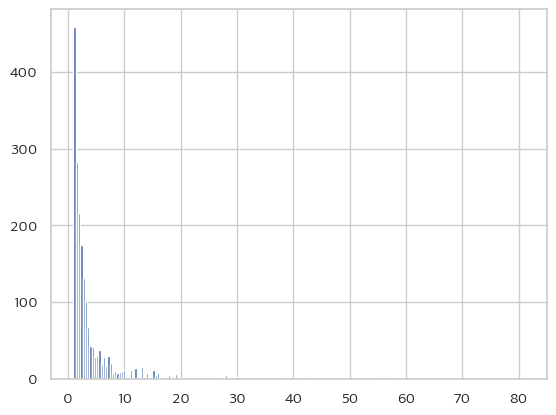

In [20]:
plt.hist(x='총외환금액',data=a, bins=200)

In [21]:
a['총외환금액'].quantile(1)

np.float64(81.0)

In [22]:
a['총외환거래건수'].describe()

count    1949.000000
mean       15.119292
std        15.360947
min         0.000000
25%         3.500000
50%         8.500000
75%        18.500000
max        70.000000
Name: 총외환거래건수, dtype: float64

In [23]:
a['총외환금액'].describe()

count    1949.000000
mean        4.268969
std         6.479664
min         1.000000
25%         1.400000
50%         2.200000
75%         4.100000
max        81.000000
Name: 총외환금액, dtype: float64

In [24]:
df2.describe().round(2)

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,월평균대출금리(%),월평균예금금리(%),기준예대마진(%),신탁보수율(trust),카드수수료율(card),수익증권/연금(fund),외환/기타(fx),채널건당(channel),수익증권수익,신탁수익,외환수익,카드수익,추정_비이자수익,총자산,기준예금이자,기준대출이자,예대마진,예대마진수익률(%),총수익,자산대비수익률(%),총채널거래금액,총채널거래건수,총거래건수,총디지털거래건수,디지털거래건수비중,총외환금액,총외환거래건수,총카드사용금액,예금이용,대출이용,카드이용,외환이용,상품다양성개수,다양성점수
count,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.0,345553.0,345553.0,345553.0,345553.0,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.0,345553.00,345553.00,345553.00,345553.00,345553.00
mean,202306.93,162.86,613.65,3.91,0.84,234.28,80.01,633.53,827.36,810.60,0.02,0.02,5.98,0.16,255.52,799.71,13.52,3.00,104.81,195.51,901.48,1149.21,3.76,0.21,0.14,0.04,0.32,0.24,4.89,0.69,4.33,0.13,0.12,1.75,20.92,2.88,0.57,1.93,17.20,780.42,315.13,1637.95,4.10,5.57,0.59,2050.69,1176.56,816.23,360.33,6.13,0.03,0.43,0.27,0.15,0.0,0.0,0.0,0.0,300.0,0.00,0.06,0.00,0.01,0.07,2653.50,2.16,7.01,4.85,0.30,4.92,0.32,1176.56,28.05,28.30,24.37,0.67,0.03,0.25,6.13,0.9,0.93,0.64,0.05,2.51,0.63
std,81.71,2447.92,40405.88,40.83,22.73,5583.80,890.66,4825.43,3896.29,3819.33,0.40,0.39,113.16,2.59,18792.89,25307.12,135.30,38.85,1961.48,4097.00,22152.70,29381.18,4.59,1.85,0.77,0.36,0.84,0.48,9.43,1.41,5.96,1.54,1.00,6.43,22.63,8.61,3.69,6.14,14.95,40518.62,5809.75,5667.29,5.28,9.67,1.30,48595.32,35017.82,25311.61,18960.08,113.26,0.58,0.05,0.05,0.02,0.0,0.0,0.0,0.0,0.0,0.01,1.49,0.00,0.11,1.50,42927.73,118.10,24.59,113.94,0.21,113.94,1.08,35017.82,30.29,30.65,26.03,0.42,0.58,1.99,113.26,0.3,0.26,0.48,0.22,0.68,0.17
min,202201.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.29,0.15,0.11,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,-19204.15,-0.35,-19204.15,-0.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00
25%,202210.00,0.36,0.00,0.00,0.00,0.00,0.00,0.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.50,6.00,8.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.50,0.43,0.00,68.00,1.00,1.00,0.00,16.10,1.10,0.00,0.00,0.00,0.00,0.41,0.27,0.14,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.00,0.00,0.00,114.00,0.00,0.28,0.19,0.26,0.20,0.27,1.10,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.0,1.00,0.00,0.00,2.00,0.50
50%,202307.00,6.80,0.00,0.00,0.00,0.00,0.00,0.00,150.00,0.00,0.00,0.00,1.10,0.00,0.00,29.00,0.00,0.00,0.00,9.60,57.00,63.00,2.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,2.00,0.00,0.00,0.00,7.50,0.00,0.00,0.00,15.00,8.30,0.00,330.00,2.00,2.00,0.00,126.00,53.17,39.50,0.00,1.10,0.00,0.44,0.29,0.15,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.00,0.00,0.00,460.00,0.02,1.41,1.24,0.39,1.26,0.39,53.17,16.00,16.00,15.00,0.94,0.00,0.00,1.10,1.0,1.00,1.00,0.00,3.00,0.75
75%,202404.00,56.00,0.00,0.00,0.00,0.00,0.00,190.00,530.00,350.00,0.00,0.00,4.60,0.00,0.14,180.00,0.66,0.00,0.30,30.00,250.00,2

In [25]:
key_vars = ['총자산', '여신한도금액', '전체거래액', '총수익']
# 총외환수익 = 0이 약 30만개정도이고, 이외의 값을 모두 이상치로 처리하기에 변별력이 큰 변수가 아님을 확인
# > 이는 활동성지표에서 외환여부(0/1)로 표현하여 활동성을 대변하는 지표로 활용할 수 있도록 함

# 총외환수익과 예대의 크기에관한 이야기는 활동성에서 규모로 다루기로함.

In [26]:
# df2는 일반 고객용 데이터프레임
# key_vars는 분석가가 선정한 핵심 변수 이름 리스트 (예: ['총자산', '전체거래액', ...])

# 이상치(VVVIP)를 판단할 조건 시리즈 (초기값: 모두 False)
is_vvvip_condition = pd.Series([False] * len(df2))

for var in key_vars:
    # IQR 계산
    Q1 = df2[var].quantile(0.25)
    Q3 = df2[var].quantile(0.75)
    IQR = Q3 - Q1
    
    # 상하단 커트라인 설정 (3.0은 아주 극단적인 값만!)
    upper_whisker = Q3 + 3.0 * IQR
    lower_whisker = Q1 - 3.0 * IQR
    
    # 양수 쪽 이상치 OR 음수 쪽 이상치 하나라도 해당하면 VVVIP
    is_vvvip_condition = is_vvvip_condition | (df2[var] > upper_whisker) | (df2[var] < lower_whisker)

# 데이터 분리
vvvip_df2 = df2[is_vvvip_condition].copy()
analysis_df2 = df2[~is_vvvip_condition].copy()

print(f"상단/하단 이상치 포함 VVVIP: {len(vvvip_df2)}명")

상단/하단 이상치 포함 VVVIP: 60393명


/var/folders/4x/fwn2w0w91c9__t6p_qlqfg080000gn/T/ipykernel_42343/605407364.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vvvip_df2 = df2[is_vvvip_condition].copy()
/var/folders/4x/fwn2w0w91c9__t6p_qlqfg080000gn/T/ipykernel_42343/605407364.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  analysis_df2 = df2[~is_vvvip_condition].copy()


1. 왜 이자+비이자수익(절대값)을 따로 봐야 할까?  
은행 입장에서 VVVIP는 **'우리한테 실제로 얼마를 벌어다 주느냐'**라는 **규모(Scale)**가 제일 중요해.  
  
A기업: 총자산 10조, 수익 1,000억 → 자산대비수익률(ROA) 1%    
B기업: 총자산 1억, 수익 5,000만 원 → 자산대비수익률(ROA) 50% 

# 지수변수 생성 전 vif확인

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [28]:
analysis_df2['총외환금액'].value_counts().sort_index()

총외환금액
0.00     274920
0.01       1626
0.02       1187
0.03        967
0.04        722
          ...  
12.00         5
13.00         1
14.00         2
15.00         2
19.00         1
Name: count, Length: 238, dtype: int64

In [29]:
# 1. 컬럼 생략 없이 다 보여줘! (None이 무제한이라는 뜻)
pd.set_option('display.max_columns', None)

print(df2.isnull().sum().sort_values())

기준년월             0
수익증권수익           0
채널건당(channel)    0
외환/기타(fx)        0
수익증권/연금(fund)    0
                ..
요구불입금금액          0
자동이체금액           0
ATM거래금액          0
스마트뱅킹거래금액        0
다양성점수            0
Length: 91, dtype: int64


In [30]:
# 1. 주희가 선정한 후보 변수 리스트 (활동성 + 수익성)
# 원본 데이터로 먼저 확인해서 '진짜 겹치는 놈'들을 잡아내자!
# 활동성 지표
vif_features1 = [
    '총예금잔액', '총대출잔액', '총채널거래금액', '총외환금액', '총카드사용금액', # 활동성-규모
    '총채널거래건수', '총외환거래건수', # 활동성-빈도
    '다양성점수' # 활동성 - 다양성
]

# 수익성 지표
vif_features2 = [
    '예대마진', '추정_비이자수익', '자산대비수익률(%)' # 수익성
]

# 검사용 데이터셋 생성 ( nan존재 시 연산불가 )
vif_data1 = analysis_df2[vif_features1]
vif_data2 = analysis_df2[vif_features2]

# 2. VIF 계산 수행
# 활동성
vif_df1 = pd.DataFrame()
vif_df1["Feature"] = vif_data1.columns
vif_df1["VIF"] = [variance_inflation_factor(vif_data1.values, i) for i in range(vif_data1.shape[1])]
# 수익성
vif_df2 = pd.DataFrame()
vif_df2["Feature"] = vif_data2.columns
vif_df2["VIF"] = [variance_inflation_factor(vif_data2.values, i) for i in range(vif_data2.shape[1])]

# 3. 결과 확인 (높은 순 정렬)
print("=== 알짜발굴단 활동성 변수 VIF 결과 ===")
print(vif_df1.sort_values(by="VIF", ascending=False))
print(f' ')
print("=== 알짜발굴단 수익성 변수 VIF 결과 ===")
print(vif_df2.sort_values(by="VIF", ascending=False))

=== 알짜발굴단 활동성 변수 VIF 결과 ===
   Feature       VIF
5  총채널거래건수  3.116054
7    다양성점수  2.620641
2  총채널거래금액  2.451479
6  총외환거래건수  1.671215
3    총외환금액  1.630431
1    총대출잔액  1.562623
0    총예금잔액  1.233569
4  총카드사용금액  1.181599
 
=== 알짜발굴단 수익성 변수 VIF 결과 ===
      Feature       VIF
0        예대마진  1.058992
2  자산대비수익률(%)  1.035692
1    추정_비이자수익  1.024039


### 셀 설명: 활동성지수 계산용 스케일러

금액·건수 변수는 단위와 분포가 매우 다르기 때문에, `log1p` 변환 후 정규화가 필요합니다. 여기서는 기본적으로 `MinMaxScaler`를 사용해 0~1 범위로 맞춥니다.


In [31]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

[총채널거래건수 통계치]
평균: 24.86 | 중앙값: 15.00 | 최빈값: 0.00


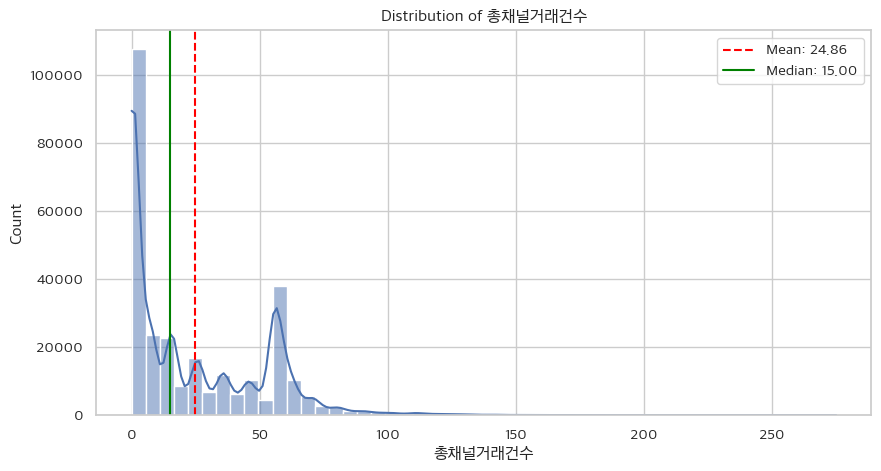

[총채널거래건수_log 통계치]
평균: 2.33 | 중앙값: 2.77 | 최빈값: 0.00


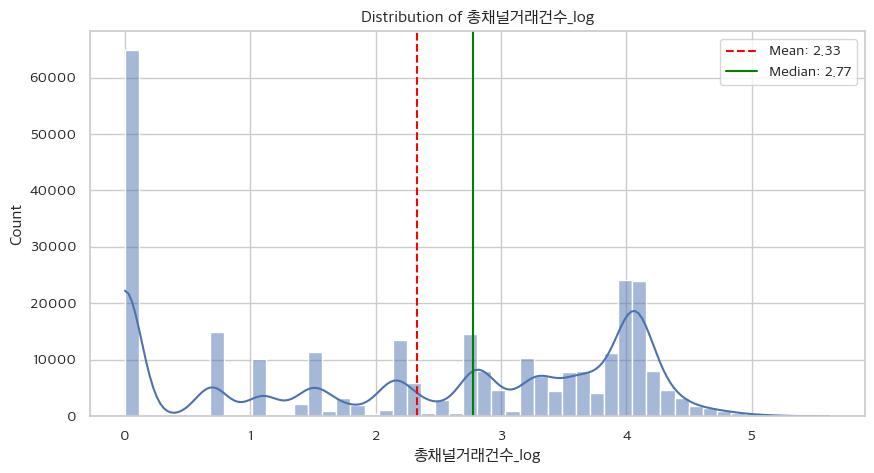

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def check_distribution(df, col):
    # 기초통계량 계산
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0] # 최빈값
    
    print(f"[{col} 통계치]")
    print(f"평균: {mean_val:,.2f} | 중앙값: {median_val:,.2f} | 최빈값: {mode_val:,.2f}")
    
    # 히스토그램 시각화
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=50)
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:,.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:,.2f}')
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

# 예시: 로그 변환 전후 비교 (총예금잔액)
# 원본 확인
check_distribution(analysis_df2, '총채널거래건수')

# 로그 변환 후 확인
analysis_df2['총채널거래건수_log'] = np.log1p(analysis_df2['총채널거래건수'])
check_distribution(analysis_df2, '총채널거래건수_log')

# 활동성지수(FAI)

In [33]:
    # 결측치는 기본적으로 0으로 대체한다.
    # 다만 실제 업무에서는 결측과 실제 0이 다를 수 있으므로 해석 시 주의가 필요하다.

In [34]:
def _get_scaler(scaler_type='minmax'):

    if scaler_type == 'minmax':
        return MinMaxScaler()
    if scaler_type == 'standard':
        return StandardScaler()
    raise ValueError("scaler_type은 'minmax' 또는 'standard'만 지원합니다.")

def _scale_series(series, scaler_type='minmax', log_transform=True):
    # 1. 숫자형 변환 (결측치는 fillna(0) 하지 않고 NaN 그대로 유지!)
    values = pd.to_numeric(series, errors='coerce').astype(float)

    # 2. 로그 변환 (음수 처리 포함)
    if log_transform:
        # inf(무한대)를 제외한 진짜 숫자들 중에서만 최솟값을 찾음
        finite_values = values[np.isfinite(values)]
        
        if not finite_values.empty:
            min_val = finite_values.min()
            if min_val < 0:
                # 평행이동해도 NaN은 그대로 NaN이야! 걱정 마.
                values = np.log1p(values - min_val)
            else:
                values = np.log1p(values)

    # 3. 스케일러 적용
    # MinMaxScaler는 NaN이 들어와도 에러를 내지 않고 NaN으로 돌려줌!
    scaler = _get_scaler(scaler_type)
    scaled = scaler.fit_transform(values.to_frame()).reshape(-1)
    
    return pd.Series(scaled, index=series.index)

In [35]:
# 1. 활동성 지표(FAI) 구성 변수
# 규모(Size): 로그 O / 빈도(Freq): 로그 O / 다양성: 이미 0~1 (로그 X)
size_vars = ['총예금잔액', '총대출잔액', '총채널거래금액', '총외환금액', '총카드사용금액']
freq_vars = ['총채널거래건수', '총외환거래건수']
diversity_vars = ['다양성점수']

# 2. 수익성 지표(FPI) 구성 변수
# 기여(Contrib): 로그 O / 효율(Eff): 비율형 (로그 X)
contrib_vars = ['예대마진', '추정_비이자수익']
eff_vars = ['자산대비수익률(%)']

In [36]:
# --- [스케일링 적용] ---

# 활동성: 규모 & 빈도 (로그 O)
for col in size_vars + freq_vars:
    analysis_df2[f'{col}_score'] = _scale_series(analysis_df2[col], scaler_type='minmax', log_transform=True)

# 수익성: 기여도 (로그 O) - 여기서 예대마진 음수가 자동으로 처리됨!
for col in contrib_vars:
    analysis_df2[f'{col}_score'] = _scale_series(analysis_df2[col], scaler_type='minmax', log_transform=True)

# 효율성 & 다양성 (로그 X)
for col in eff_vars + diversity_vars:
    # 다양성점수_score로 컬럼명을 맞추기 위해 통일
    col_name = '다양성점수' if col == '다양성점수' else col
    analysis_df2[f'{col_name}_score'] = _scale_series(analysis_df2[col], scaler_type='minmax', log_transform=False)

# --- [최종 지표 합산 로직 유지] ---
analysis_df2['규모점수'] = analysis_df2[[f'{c}_score' for c in size_vars]].mean(axis=1)
analysis_df2['빈도점수'] = analysis_df2[[f'{c}_score' for c in freq_vars]].mean(axis=1)
analysis_df2['FAI'] = (analysis_df2['규모점수'] + analysis_df2['빈도점수'] + analysis_df2['다양성점수_score']) / 3

analysis_df2['수익기여점수'] = analysis_df2[[f'{c}_score' for c in contrib_vars]].mean(axis=1)
analysis_df2['수익효율점수'] = analysis_df2[[f'{c}_score' for c in eff_vars]].mean(axis=1)
analysis_df2['FPI'] = (analysis_df2['수익기여점수'] + analysis_df2['수익효율점수']) / 2

print("FAI, FPI 지표 생성 완료! 🚀")
print(analysis_df2[['FAI', 'FPI']].describe())

FAI, FPI 지표 생성 완료! 🚀
                 FAI            FPI
count  285160.000000  285160.000000
mean        0.373496       0.203784
std         0.124538       0.013785
min         0.000000       0.021495
25%         0.274491       0.194866
50%         0.383726       0.198579
75%         0.478378       0.208247
max         0.806615       0.694735


---

기존꺼

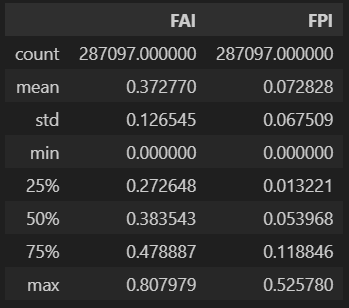

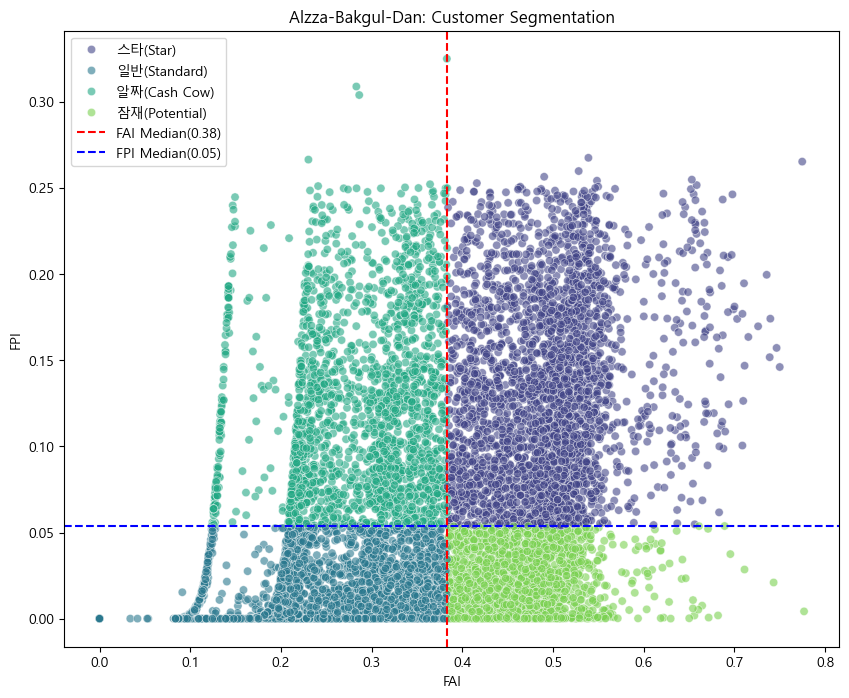

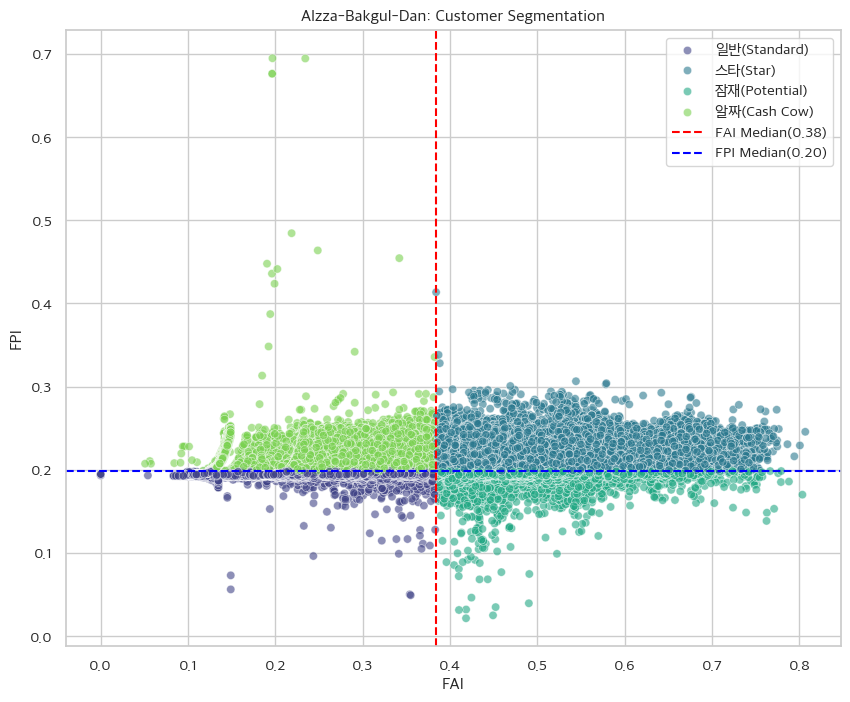

등급
일반(Standard)     85662
스타(Star)         85662
잠재(Potential)    56918
알짜(Cash Cow)     56918
Name: count, dtype: int64


In [37]:
# 1. 중앙값(Median) 기준선 설정
fai_cutoff = analysis_df2['FAI'].median() # 0.3835
fpi_cutoff = analysis_df2['FPI'].median() # 0.2005

# 2. 4사분면 등급 부여 함수
def get_segment(row):
    if row['FAI'] >= fai_cutoff and row['FPI'] >= fpi_cutoff:
        return '스타(Star)'         # 활동도 높고 수익도 높음
    elif row['FAI'] < fai_cutoff and row['FPI'] >= fpi_cutoff:
        return '알짜(Cash Cow)'    # 활동은 적지만 수익은 높음 (주희의 타겟!)
    elif row['FAI'] >= fai_cutoff and row['FPI'] < fpi_cutoff:
        return '잠재(Potential)'   # 활동은 많은데 수익이 낮음 (성장 가능성)
    else:
        return '일반(Standard)'    # 둘 다 낮음

analysis_df2['등급'] = analysis_df2.apply(get_segment, axis=1)

# 3. 사분면 시각화 (Scatter Plot)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=analysis_df2, x='FAI', y='FPI', hue='등급', 
                palette='viridis', alpha=0.6)
plt.axvline(fai_cutoff, color='red', linestyle='--', label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', label=f'FPI Median({fpi_cutoff:.2f})')
plt.title('Alzza-Bakgul-Dan: Customer Segmentation')
plt.legend()
plt.show()

print(analysis_df2['등급'].value_counts())

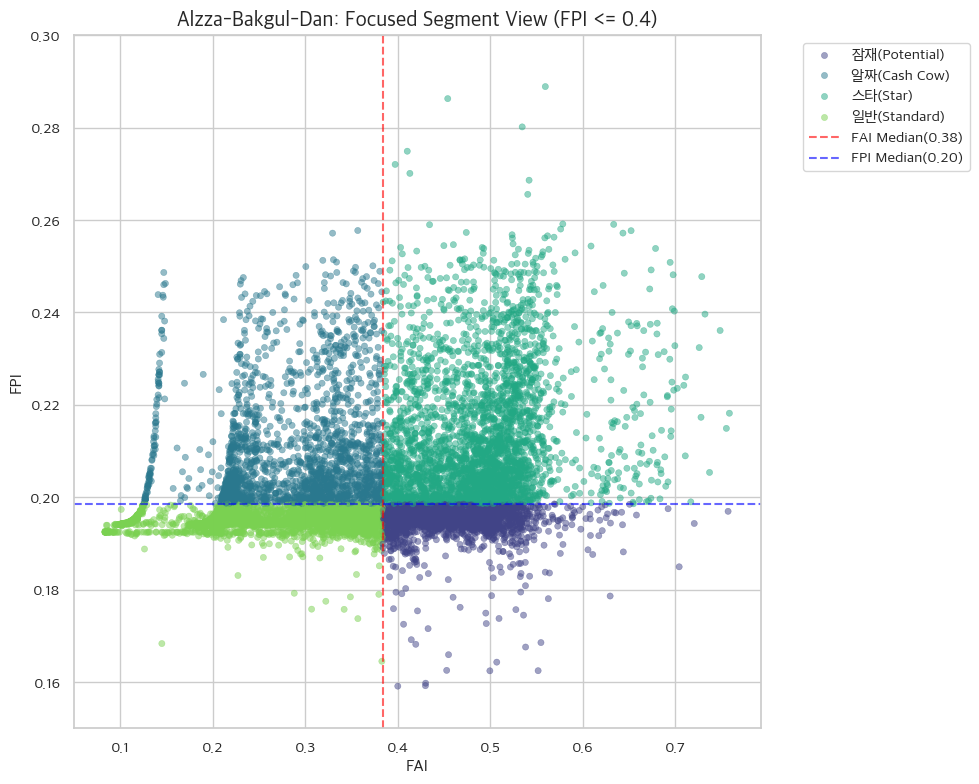

In [38]:
plt.figure(figsize=(10, 8))

# 1. 점 크기(s)와 투명도(alpha)를 조절해서 겹침 현상 해결
sns.scatterplot(data=analysis_df2.sample(10000), x='FAI', y='FPI', hue='등급', 
                palette='viridis', s=20, alpha=0.5, edgecolor=None)

# 2. 기준선 (Median 기준)
plt.axvline(fai_cutoff, color='red', linestyle='--', alpha=0.6, label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', alpha=0.6, label=f'FPI Median({fpi_cutoff:.2f})')

# 3. [핵심] Y축 범위를 0.4까지로 제한 (시각적 밀도 강화)
plt.ylim(0.15, 0.3) 

plt.title('Alzza-Bakgul-Dan: Focused Segment View (FPI <= 0.4)', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 밖으로 빼서 그림 안 가리게!
plt.tight_layout()
plt.show()

In [39]:
# 등급별로 우리가 만든 원본 변수들의 평균을 비교해보자
final_profile = analysis_df2.groupby('등급')[['총예금잔액', '총대출잔액', '예대마진', '총채널거래건수', 'FAI', 'FPI']].mean()
final_profile2 = analysis_df2.groupby('등급')[['총예금잔액', '총대출잔액', '예대마진', '총채널거래건수', 'FAI', 'FPI']].median()

# FPI(수익성) 높은 순으로 정렬해서 확인
print("=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===")
print(final_profile.sort_values(by='FPI', ascending=False))
print("=== 알짜발굴단 등급별 프로파일링 결과 (median) ===")
print(final_profile2.sort_values(by='FPI', ascending=False))

=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===
                    총예금잔액        총대출잔액      예대마진    총채널거래건수       FAI  \
등급                                                                      
스타(Star)        93.320849  1189.898765  4.788992  41.926630  0.490201   
알짜(Cash Cow)    24.427908  1039.094927  4.381559   4.828569  0.286268   
일반(Standard)    23.511130    68.774181  0.223483   9.023896  0.256998   
잠재(Potential)  139.213743   113.366344  0.092752  43.019449  0.460415   

                    FPI  
등급                       
스타(Star)       0.214044  
알짜(Cash Cow)   0.211227  
일반(Standard)   0.194809  
잠재(Potential)  0.194407  
=== 알짜발굴단 등급별 프로파일링 결과 (median) ===
               총예금잔액  총대출잔액      예대마진  총채널거래건수       FAI       FPI
등급                                                                
스타(Star)       24.30  830.0  3.294190     45.5  0.492928  0.209526
알짜(Cash Cow)    1.40  690.0  2.851450      1.0  0.300288  0.206446
잠재(Potential)  28.95   90.0  0.204000     45.0  0.458078  0.195144


In [40]:
# 등급별로 우리가 만든 원본 변수들의 평균을 비교해보자
final_profile1 = analysis_df2.groupby('법인_고객등급')[['총예금잔액', '예대마진', '총채널거래건수','FPI','FAI']].mean()
final_profile22 = analysis_df2.groupby('법인_고객등급')[['총예금잔액', '예대마진', '총채널거래건수','FPI','FAI']].median()
# FPI(수익성) 높은 순으로 정렬해서 확인
print("=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===")
print(final_profile1.sort_values(by='FPI', ascending=False))
print("=== 알짜발굴단 등급별 프로파일링 결과 (median) ===")
print(final_profile22.sort_values(by='FPI', ascending=False))

=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===
              총예금잔액      예대마진    총채널거래건수       FPI       FAI
법인_고객등급                                                     
최우수      167.541164  4.690571  35.175408  0.213108  0.440329
우수        34.202462  1.809478  26.786005  0.201482  0.386989
일반         8.915514  0.840448  12.610787  0.197335  0.293059
=== 알짜발굴단 등급별 프로파일링 결과 (median) ===
         총예금잔액    예대마진  총채널거래건수       FPI       FAI
법인_고객등급                                            
최우수      46.00  3.5268     35.0  0.210752  0.463726
우수        7.60  1.0360     17.0  0.198957  0.399098
일반        0.62  0.2254      2.0  0.195068  0.285511


In [41]:
cc= analysis_df2[analysis_df2['등급']=='알짜(Cash Cow)']
ccc= analysis_df2[analysis_df2['등급']=='잠재(Potential)']
ccc1= analysis_df2[analysis_df2['등급']=='스타(Star)']
ccc2= analysis_df2[analysis_df2['등급']=='일반(Standard)']

In [42]:
print(f'일반(Standard) 내 법인 고객등급의 비중')
print(ccc2['법인_고객등급'].value_counts())
print(f'잠재(Potential) 내 법인 고객등급의 비중')
print(ccc['법인_고객등급'].value_counts())
print(f'알짜(Cash Cow) 내 법인 고객등급의 비중')
print(cc['법인_고객등급'].value_counts())
print(f'스타(Star) 내 법인 고객등급의 비중')
print(ccc1['법인_고객등급'].value_counts())


일반(Standard) 내 법인 고객등급의 비중
법인_고객등급
일반     58357
우수     22323
최우수     4982
Name: count, dtype: int64
잠재(Potential) 내 법인 고객등급의 비중
법인_고객등급
우수     27042
일반     16456
최우수    13420
Name: count, dtype: int64
알짜(Cash Cow) 내 법인 고객등급의 비중
법인_고객등급
우수     24817
최우수    20511
일반     11590
Name: count, dtype: int64
스타(Star) 내 법인 고객등급의 비중
법인_고객등급
최우수    50219
우수     30269
일반      5174
Name: count, dtype: int64


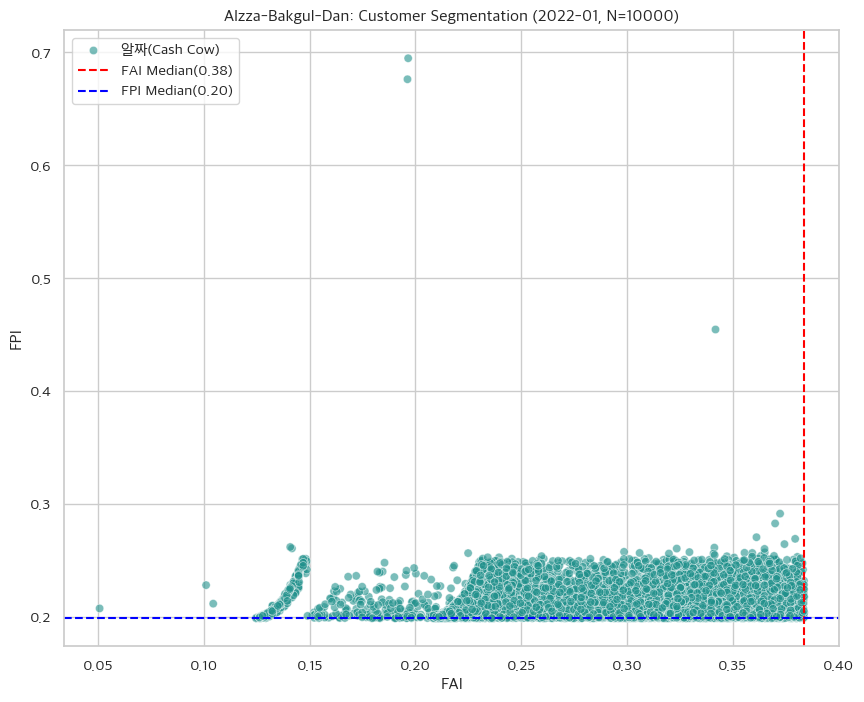

등급
알짜(Cash Cow)    56918
Name: count, dtype: int64


In [43]:
# 샘플링 개수를 데이터 크기에 맞게 자동 조절
sample_size = min(len(cc), 10000)

plt.figure(figsize=(10, 8))
# sample_size 만큼만 추출
sns.scatterplot(data=cc.sample(sample_size), x='FAI', y='FPI', hue='등급', 
                palette='viridis', alpha=0.6)

plt.axvline(fai_cutoff, color='red', linestyle='--', label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', label=f'FPI Median({fpi_cutoff:.2f})')
plt.title(f'Alzza-Bakgul-Dan: Customer Segmentation (2022-01, N={sample_size})')
plt.legend()
plt.show()

print(cc['등급'].value_counts())

-------------------
----------------

# 총 가설검정


## 기존 등급 보완 필요성 가설검정

본 가설검정의 목적은 기존 안정성 중심 기업등급을 부정하는 것이 아니라,
기존 등급이 활동성과 수익성을 어느 정도 설명하는지 확인하고,
동일 등급 내부의 이질성과 숨은 우량고객의 존재를 통해 보완적 평가관점의 필요성을 보여주는 데 있습니다.


In [44]:

import itertools
import numpy as np
import pandas as pd
from scipy import stats

try:
    from statsmodels.stats.multitest import multipletests
    HAS_MULTITEST = True
except Exception:
    HAS_MULTITEST = False

try:
    from statsmodels.stats.oneway import anova_oneway
    HAS_WELCH = True
except Exception:
    HAS_WELCH = False

try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    HAS_TUKEY = True
except Exception:
    HAS_TUKEY = False

hyp_df = analysis_df2.copy()
hyp_df = hyp_df.dropna(subset=['법인_고객등급', 'FAI', 'FPI', '등급']).copy()
print(f'가설검정 분석 표본 수: {len(hyp_df):,}명')
print(hyp_df['법인_고객등급'].value_counts())
print(hyp_df['등급'].value_counts())


가설검정 분석 표본 수: 285,160명
법인_고객등급
우수     104451
일반      91577
최우수     89132
Name: count, dtype: int64
등급
일반(Standard)     85662
스타(Star)         85662
잠재(Potential)    56918
알짜(Cash Cow)     56918
Name: count, dtype: int64


# 전체 프로젝트 가설검정의 흐름
## 기존등급에서 왜 수익+활동성을 추가해서 봐야되냐의 근거
1. 기존등급별 활동성+수익성을 본거
반영하지않는건 아니고,
>> 이거에 대한 제대로된 근거

기존등급별로 존재한다. >
기존등급도 일정부분은 활동성과 수익성이 보이는데,

2. 기존기업등급과 사분면 등급이 완전히 일치하는가?(카이제곱)
세부로 나누는 이유를 보기위해서.
> 기존등급과 사분면은 관련이 있으나, 완전히 같은건 아니지

	>> 기존등급이 놓칠 수 있는 영업적 차이를 보완적으로 설명하는 가설검정



3. 동일한 기존 기업등급 내부서 사분면별 활동성 수익성 차이가 존재하냐.
 >> 다 유의하다
해서 사후검정도 다 유의하고 다다르다.



== 기존등급과 더불어, 수익성과 활동성(새세그먼트)을 반영한 것이 더 세분화 할 수 있다.



## 새 세그먼트 비교 근거 (수익+활동성 왜 추가하는지에 대해 말했으니 이제 세그먼트 비교근거)
4. 새로운그룹으로 비교 (비교전제 : 활동성할거면 좌우로 비교하고 수익성할거면 상하로 나눠서 비교)
유의



5. 알짜-스타 자산대비수익률 차이 (수익효율성에 대한 이야기)
기본적으로 자산이 차이가날거임.
 :: 자산대비 수익효율성을 따졌을 때 알짜가 더 높다.

## 새 세그먼트 비교

6. [핵심발견] '일반-알짜'의 반전 드라마
내용: 등급 낮다고 무시했는데, '알짜' 딱지 붙은 '일반'은 우수 등급보다 가성비가 쩔어!
팩트: * 수익 효율(FPI)은 일반=우수 ($p=0.316$ 차이 없음)
보정 후 수익 밀도(가성비)는 일반 > 우수 ($1.34 > 1.22$) 역전 확인! :fire:



7. 세그먼트별 변수들 비모수 검정한거

8. 업종x세그먼트 카이제곱 검정 ( + 지역별 )
알짜는 부동산이 젤 많이 나옴~!!
>> 많이 나온거 위주로 보면 좋아보인다고 함

9. [실행전략] 타겟 확정 및 제언 (STEP 4 & 현황)
내용: "그래서 누구한테 마케팅할 건데?"
팩트: [제조업 + 대구·경북(TK) + 일반 등급 알짜] 2,400개 기업 식별!
제언: 덩치(자산) 중심에서 실속(수익 밀도) 중심으로 마케팅 패러다임을 바꿔야 함!


------------------------

### 가설 1. 기존 기업등급별로 활동성(FAI)과 수익성(FPI) 분포 차이가 존재하는가?

- 귀무가설(H0): 법인 고객등급별 FAI 분포와 FPI 분포는 같다.
- 대립가설(H1): 법인 고객등급별 FAI 또는 FPI 분포는 적어도 하나 이상 다르다.

이 가설은 기존 등급이 활동성과 수익성을 어느 정도 반영하는지 확인하기 위해 수행합니다.
연속형 지표 비교는 순위 기반 비모수 검정으로 통일하여 `Kruskal-Wallis 검정`을 사용합니다.


기존 등급별로 FAI, FPI 차이가 실제로 존재하는지 확인한다

- 기존 기업등급에도 활동성과 수익성이 일부 반영되어 있을 가능성은 있습니다.(반영 정도를 알 수 없다)
- 다만 표본이 매우 크고 연속형 지표 비교 전반을 비모수 검정으로 통일하기 위해, 본 검정에서는 기존 등급별 활동성과 수익성의 순위 기반 분포 차이가 존재하는지 먼저 확인했습니다.


In [45]:
def run_group_distribution_test(df, group_col, value_col):
    temp = df[[group_col, value_col]].dropna().copy()
    groups = [pd.to_numeric(g[value_col], errors='coerce').dropna().values for _, g in temp.groupby(group_col)]
    h_stat, p_val = stats.kruskal(*groups)
    return {
        '지표': value_col,
        '집단수': temp[group_col].nunique(),
        '선택 모형': 'Kruskal-Wallis',
        'H-stat': h_stat,
        'p-value': p_val,
        '유의여부(5%)': '유의' if p_val < 0.05 else '비유의'
    }

hyp1_results = pd.DataFrame([
    run_group_distribution_test(hyp_df, '법인_고객등급', 'FAI'),
    run_group_distribution_test(hyp_df, '법인_고객등급', 'FPI')
])

grade_profile = hyp_df.groupby('법인_고객등급')[['FAI', 'FPI']].agg(['mean', 'median', 'count'])
display(grade_profile.round(4))
display(hyp1_results.round(4))


FAI                     FPI                
           mean  median   count    mean  median   count
법인_고객등급                                                
우수       0.3870  0.3991  104451  0.2015  0.1990  104451
일반       0.2931  0.2855   91577  0.1973  0.1951   91577
최우수      0.4403  0.4637   89132  0.2131  0.2108   89132

,지표,집단수,선택 모형,H-stat,p-value,유의여부(5%)
0,FAI,3,Kruskal-Wallis,67008.2303,0.0,유의
1,FPI,3,Kruskal-Wallis,69852.4022,0.0,유의


In [46]:
def run_posthoc_test(df, group_col, value_col, selected_model, label):
    temp = df[[group_col, value_col]].dropna().copy()
    groups = sorted(temp[group_col].unique())
    print(f'[{label}] 사후검정 결과')

    if selected_model == 'Kruskal-Wallis':
        import scikit_posthocs as sp
        dunn_df = sp.posthoc_dunn(temp, val_col=value_col, group_col=group_col, p_adjust='bonferroni')
        display(dunn_df.round(4))
        return dunn_df.round(4)

    if selected_model == 'ANOVA' and HAS_TUKEY:
        tukey = pairwise_tukeyhsd(endog=temp[value_col], groups=temp[group_col], alpha=0.05)
        tukey_df = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
        if 'p-adj' in tukey_df.columns:
            tukey_df = tukey_df.sort_values('p-adj')
        display(tukey_df)
        return tukey_df

    pair_rows = []
    for g1, g2 in itertools.combinations(groups, 2):
        x = pd.to_numeric(temp.loc[temp[group_col] == g1, value_col], errors='coerce').dropna()
        y = pd.to_numeric(temp.loc[temp[group_col] == g2, value_col], errors='coerce').dropna()
        t_stat, p_val = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
        pair_rows.append({'비교': f'{g1} vs {g2}', 't-stat': t_stat, 'p-value': p_val})

    pair_df = pd.DataFrame(pair_rows)
    if HAS_MULTITEST and not pair_df.empty:
        reject, p_adj, _, _ = multipletests(pair_df['p-value'], alpha=0.05, method='fdr_bh')
        pair_df['FDR 보정 p-value'] = p_adj
        pair_df['유의여부(5%)'] = np.where(reject, '유의', '비유의')
        pair_df = pair_df.sort_values(['FDR 보정 p-value', 'p-value'])
    else:
        pair_df['유의여부(5%)'] = np.where(pair_df['p-value'] < 0.05, '유의', '비유의')
        pair_df = pair_df.sort_values('p-value')
    display(pair_df.round(4))
    return pair_df


#### 가설 1 사후검정

전체 분포 차이가 유의하더라도, 실제로 어느 기존 등급끼리 차이가 나는지는 사후검정으로 확인해야 합니다.
여기서는 `Kruskal-Wallis`가 유의한 경우 `Dunn 사후검정`을 사용합니다.


In [47]:
hyp1_posthoc = {}
for metric in ['FAI', 'FPI']:
    row = hyp1_results[hyp1_results['지표'] == metric].iloc[0]
    if row['유의여부(5%)'] == '유의':
        hyp1_posthoc[metric] = run_posthoc_test(hyp_df, '법인_고객등급', metric, row['선택 모형'], f'가설 1 - {metric}')
        print('-' * 80)


[가설 1 - FAI] 사후검정 결과


,우수,일반,최우수
우수,1.0,0.0,0.0
일반,0.0,1.0,0.0
최우수,0.0,0.0,1.0


--------------------------------------------------------------------------------
[가설 1 - FPI] 사후검정 결과


,우수,일반,최우수
우수,1.0,0.0,0.0
일반,0.0,1.0,0.0
최우수,0.0,0.0,1.0


--------------------------------------------------------------------------------


In [48]:
for metric in ['FAI', 'FPI']:
    row = hyp1_results[hyp1_results['지표'] == metric].iloc[0]
    print(f'[{metric}] {row["선택 모형"]} 결과: H-stat={row["H-stat"]:.4f}, p-value={row["p-value"]:.10f}, 유의여부={row["유의여부(5%)"]}')

print('해석: 유의하다면 기존 기업등급이 활동성과 수익성을 완전히 무시한 것은 아니며, 순위 기반 분포 차이 수준에서 일정 부분 반영하고 있다고 볼 수 있습니다.')
print('의미: 하지만 이 결과만으로 기존 등급이 영업적 가치까지 충분히 설명한다고 결론 내릴 수는 없으므로, 다음 가설에서 사분면과의 관계를 추가로 확인합니다.')


[FAI] Kruskal-Wallis 결과: H-stat=67008.2303, p-value=0.0000000000, 유의여부=유의
[FPI] Kruskal-Wallis 결과: H-stat=69852.4022, p-value=0.0000000000, 유의여부=유의
해석: 유의하다면 기존 기업등급이 활동성과 수익성을 완전히 무시한 것은 아니며, 순위 기반 분포 차이 수준에서 일정 부분 반영하고 있다고 볼 수 있습니다.
의미: 하지만 이 결과만으로 기존 등급이 영업적 가치까지 충분히 설명한다고 결론 내릴 수는 없으므로, 다음 가설에서 사분면과의 관계를 추가로 확인합니다.


기존 기업등급은 활동성과 수익성을 전혀 반영하지 않는 체계는 아닙니다. 실제로 최우수 > 우수 > 일반 순으로 평균 차이가 분명하게 나타났습니다. 따라서 기존 등급도 일정 부분은 영업적 특성과 연결되어 있다고 볼 수 있습니다.


### 가설 2. 기존 기업등급과 사분면 등급은 완전히 일치하는가?

- 귀무가설(H0): 법인 고객등급과 사분면 등급은 독립이다.
- 대립가설(H1): 법인 고객등급과 사분면 등급은 독립이 아니다.

이 가설은 기존 등급과 새 세그먼트가 관련은 있는지, 그리고 완전히 같은 고객을 잡아내는지 확인하기 위해 수행합니다.
두 변수 모두 범주형이므로 `카이제곱 검정`과 `Cramer's V`를 사용합니다.


기존 등급과 새로 만든 사분면이 완전히 무관한지, 아니면 어느 정도 겹치는지를 먼저 봐야 합니다. 만약 두 체계가 완전히 똑같다면 새 사분면의 추가 의미가 약해지고, 반대로 어느 정도 관련은 있지만 완전히 같지는 않다면 보완적 관점이라는 주장이 설득력을 갖게 됩니다.

In [49]:

ct = pd.crosstab(hyp_df['법인_고객등급'], hyp_df['등급'])
ratio_ct = pd.crosstab(hyp_df['법인_고객등급'], hyp_df['등급'], normalize='index') * 100
chi2, p_val, dof, expected = stats.chi2_contingency(ct)
n = ct.to_numpy().sum()
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 and n > 0 else np.nan

print(f'카이제곱 통계량: {chi2:.4f}')
print(f'p-value: {p_val:.10f}')
print(f'자유도(dof): {dof}')
print(f"Cramer's V: {cramers_v:.4f}")
display(ct)
display(ratio_ct.round(2))


카이제곱 통계량: 100355.9117
p-value: 0.0000000000
자유도(dof): 6
Cramer's V: 0.4195


등급,스타(Star),알짜(Cash Cow),일반(Standard),잠재(Potential)
법인_고객등급,,,,
우수,30269,24817,22323,27042
일반,5174,11590,58357,16456
최우수,50219,20511,4982,13420


등급,스타(Star),알짜(Cash Cow),일반(Standard),잠재(Potential)
법인_고객등급,,,,
우수,28.98,23.76,21.37,25.89
일반,5.65,12.66,63.72,17.97
최우수,56.34,23.01,5.59,15.06


In [50]:

print('해석: p-value가 매우 작으면 기존 기업등급과 사분면 등급은 관련이 있다고 볼 수 있습니다.')
print("다만 Cramer's V가 아주 크지 않다면, 두 체계가 완전히 같은 고객을 분류한다고 보기는 어렵습니다.")
print('의미: 이는 기존 등급을 대체하자는 것이 아니라, 기존 등급 위에 활동성·수익성 세그먼트를 덧붙일 필요가 있음을 시사합니다.')


해석: p-value가 매우 작으면 기존 기업등급과 사분면 등급은 관련이 있다고 볼 수 있습니다.
다만 Cramer's V가 아주 크지 않다면, 두 체계가 완전히 같은 고객을 분류한다고 보기는 어렵습니다.
의미: 이는 기존 등급을 대체하자는 것이 아니라, 기존 등급 위에 활동성·수익성 세그먼트를 덧붙일 필요가 있음을 시사합니다.


기존 등급과 새 사분면은 분명 관련이 있습니다. 최우수일수록 스타 비중이 높고, 일반일수록 일반(Standard) 비중이 높습니다. 하지만 두 체계가 완전히 같은 것은 아닙니다. 예를 들어 우수 안에도 여러 사분면이 섞여 있고, 일반 안에도 스타와 알짜가 존재합니다. 따라서 기존 등급만으로는 고객의 영업적 특성을 충분히 설명하지 못하고, 사분면 세분화가 보완적으로 필요하다고 해석할 수 있습니다.

=> 기존 등급이 놓칠 수 있는 영업적 차이를 보완적으로 설명하는 가설검정이라고 볼 수 있습니다.

### 가설 3. 동일한 기존 기업등급 내부에서도 사분면별 활동성·수익성 분포 차이가 존재하는가?

- 귀무가설(H0): 동일한 기존 기업등급 내부에서 사분면별 FAI 분포와 FPI 분포는 같다.
- 대립가설(H1): 동일한 기존 기업등급 내부에서 사분면별 FAI 또는 FPI 분포는 적어도 하나 이상 다르다.

이 가설은 같은 기존 등급 안에서도 고객의 영업적 가치와 성장 가능성이 서로 다른지를 확인하기 위해 수행합니다.
즉, 기존 등급만으로는 내부 고객을 충분히 세분화하기 어렵다는 점을 보여주기 위한 검정이며, 여기서도 연속형 지표 비교는 `Kruskal-Wallis 검정`으로 통일합니다.


동일 등급 내부에서는 활동성과 수익성 측면에서 서로 다른 고객군이 존재하는지 확인한다.

- 같은 기존 등급이라도 사분면에 따라 영업적 특징이 다를 수 있다.
- 따라서 본 검정에서는 기존 등급 내부에서 사분면별 FAI, FPI의 순위 기반 분포 차이가 실제로 존재하는지 확인했습니다.


In [51]:
def run_within_grade_segment_test(df, grade_label, metric):
    temp = df[df['법인_고객등급'] == grade_label][['등급', metric]].dropna().copy()
    temp = temp.groupby('등급').filter(lambda g: len(g) >= 30)
    groups = [pd.to_numeric(g[metric], errors='coerce').dropna().values for _, g in temp.groupby('등급')]
    if len(groups) < 2:
        return None
    h_stat, p_val = stats.kruskal(*groups)
    return {
        '기존등급': grade_label,
        '지표': metric,
        '집단수': temp['등급'].nunique(),
        '선택 모형': 'Kruskal-Wallis',
        'H-stat': h_stat,
        'p-value': p_val,
        '유의여부(5%)': '유의' if p_val < 0.05 else '비유의'
    }

rows = []
for grade_label in sorted(hyp_df['법인_고객등급'].dropna().unique()):
    for metric in ['FAI', 'FPI']:
        result = run_within_grade_segment_test(hyp_df, grade_label, metric)
        if result is not None:
            rows.append(result)

hyp3_results = pd.DataFrame(rows)
display(hyp3_results.round(4))


,기존등급,지표,집단수,선택 모형,H-stat,p-value,유의여부(5%)
0,우수,FAI,4,Kruskal-Wallis,77797.5882,0.0,유의
1,우수,FPI,4,Kruskal-Wallis,78137.9974,0.0,유의
2,일반,FAI,4,Kruskal-Wallis,50663.7968,0.0,유의
3,일반,FPI,4,Kruskal-Wallis,41677.8344,0.0,유의
4,최우수,FAI,4,Kruskal-Wallis,55291.2552,0.0,유의
5,최우수,FPI,4,Kruskal-Wallis,43838.6931,0.0,유의


In [52]:
for grade_label in sorted(hyp_df['법인_고객등급'].dropna().unique()):
    temp = hyp_df[hyp_df['법인_고객등급'] == grade_label]
    profile = temp.groupby('등급')[['FAI', 'FPI']].median().sort_values(['FPI', 'FAI'], ascending=False)
    print(f'[{grade_label}] 내부 사분면별 중앙값 프로파일')
    display(profile.round(4))


[우수] 내부 사분면별 중앙값 프로파일


,FAI,FPI
등급,,
스타(Star),0.4787,0.2041
알짜(Cash Cow),0.3005,0.2034
일반(Standard),0.3004,0.1957
잠재(Potential),0.4678,0.1956


[일반] 내부 사분면별 중앙값 프로파일


,FAI,FPI
등급,,
스타(Star),0.4530,0.2046
알짜(Cash Cow),0.2614,0.2029
잠재(Potential),0.4370,0.1951
일반(Standard),0.2209,0.1946


[최우수] 내부 사분면별 중앙값 프로파일


,FAI,FPI
등급,,
알짜(Cash Cow),0.3130,0.2157
스타(Star),0.5073,0.2154
잠재(Potential),0.4857,0.1935
일반(Standard),0.3196,0.1926


In [53]:
if not hyp3_results.empty:
    sig_count = (hyp3_results['유의여부(5%)'] == '유의').sum()
    print(f'가설 3 결과: 총 {len(hyp3_results)}건 중 {sig_count}건이 유의하게 나타났습니다.')
    print('해석: 동일한 기존 기업등급 내부에서도 사분면에 따라 활동성과 수익성의 순위 기반 분포 차이가 다르다면, 같은 등급 안에서도 관리 전략을 달리 가져가야 함을 의미합니다.')
    print('의미: 이는 기존 등급만으로는 중소기업 내부의 영업적 가치와 성장 가능성을 충분히 설명하기 어렵다는 근거가 됩니다.')


가설 3 결과: 총 6건 중 6건이 유의하게 나타났습니다.
해석: 동일한 기존 기업등급 내부에서도 사분면에 따라 활동성과 수익성의 순위 기반 분포 차이가 다르다면, 같은 등급 안에서도 관리 전략을 달리 가져가야 함을 의미합니다.
의미: 이는 기존 등급만으로는 중소기업 내부의 영업적 가치와 성장 가능성을 충분히 설명하기 어렵다는 근거가 됩니다.


같은 기존 등급 안에서도 활동성과 수익성의 분포가 크게 다릅니다. 즉 기존 등급은 하나의 큰 틀로는 의미가 있지만, 그 내부 고객은 결코 균질하지 않습니다. 그래서 영업 전략이나 고객 관리 우선순위를 정할 때는 기존 등급만 보는 것이 아니라, 같은 등급 안에서도 스타, 알짜, 잠재, 일반처럼 다시 나눠 볼 필요가 있습니다.


#### 가설 3 사후검정

동일 기존 등급 내부에서 전체 분포 차이가 유의하더라도, 어느 사분면끼리 차이가 나는지는 사후검정으로 별도 확인해야 합니다.
아래에서는 기존 등급별로 `FAI`, `FPI`에 대한 `Dunn 사후검정`을 수행합니다.


In [54]:
hyp3_posthoc = {}
for _, row in hyp3_results.iterrows():
    if row['유의여부(5%)'] != '유의':
        continue
    grade_label = row['기존등급']
    metric = row['지표']
    temp = hyp_df[hyp_df['법인_고객등급'] == grade_label].copy()
    hyp3_posthoc[(grade_label, metric)] = run_posthoc_test(temp, '등급', metric, row['선택 모형'], f'가설 3 - {grade_label} - {metric}')
    print('-' * 80)


[가설 3 - 우수 - FAI] 사후검정 결과


,스타(Star),알짜(Cash Cow),일반(Standard),잠재(Potential)
스타(Star),1.0,0.0,0.0,0.0
알짜(Cash Cow),0.0,1.0,1.0,0.0
일반(Standard),0.0,1.0,1.0,0.0
잠재(Potential),0.0,0.0,0.0,1.0


--------------------------------------------------------------------------------
[가설 3 - 우수 - FPI] 사후검정 결과


,스타(Star),알짜(Cash Cow),일반(Standard),잠재(Potential)
스타(Star),1.0,0.0,0.0000,0.0000
알짜(Cash Cow),0.0,1.0,0.0000,0.0000
일반(Standard),0.0,0.0,1.0000,0.8056
잠재(Potential),0.0,0.0,0.8056,1.0000


--------------------------------------------------------------------------------
[가설 3 - 일반 - FAI] 사후검정 결과


...

--------------------------------------------------------------------------------
[가설 3 - 최우수 - FAI] 사후검정 결과


,스타(Star),알짜(Cash Cow),일반(Standard),잠재(Potential)
스타(Star),1.0,0.0000,0.0000,0.0
알짜(Cash Cow),0.0,1.0000,0.0345,0.0
일반(Standard),0.0,0.0345,1.0000,0.0
잠재(Potential),0.0,0.0000,0.0000,1.0


--------------------------------------------------------------------------------
[가설 3 - 최우수 - FPI] 사후검정 결과


,스타(Star),알짜(Cash Cow),일반(Standard),잠재(Potential)
스타(Star),1.0,0.0,0.0,0.0
알짜(Cash Cow),0.0,1.0,0.0,0.0
일반(Standard),0.0,0.0,1.0,1.0
잠재(Potential),0.0,0.0,1.0,1.0


--------------------------------------------------------------------------------


동일 등급 내부에서도 대부분의 사분면쌍이 FAI 또는 FPI에서 유의하게 차이 났기 때문에, 사분면 분류가 단순한 이름 붙이기가 아니라 실제 특성 차이를 반영하는 세분화라고 볼 수 있습니다.



### 최종 정리

- 기존 기업등급은 안정성 중심 종합평가 체계로서 활동성과 수익성을 어느 정도 반영하고 있습니다.
- 하지만 기존 등급과 사분면 등급이 완전히 일치하지 않고, 동일 등급 내부에서도 FAI와 FPI 차이가 존재할 수 있습니다.
- 따라서 기존 등급은 유지하되, 활동성·수익성 기반 세그먼트를 함께 활용해야 숨은 우량 중소기업과 잠재 우량고객을 더 정밀하게 발굴할 수 있습니다.

즉, 본 분석의 결론은 `기존 등급의 대체`가 아니라 `기존 등급의 보완`입니다.


# 가설(예빈)

### 가설 4. 사분면의 활동성 축 분류는 실제 활동성 차이를 유의하게 반영하는가?

- 귀무가설(H0): 활동성 고집단과 저집단의 FAI 분포 차이는 없다.
- 대립가설(H1): 활동성 고집단과 저집단의 FAI 분포 차이는 있다.

이 가설은 새 사분면의 좌우 축이 실제 활동성 차이를 잘 반영하는지 검증하기 위해 수행합니다.
고집단은 `스타(Star) + 잠재(Potential)`, 저집단은 `알짜(Cash Cow) + 일반(Standard)`으로 정의하고 `Mann-Whitney U 검정`을 사용합니다.

### 가설 5. 사분면의 수익성 축 분류는 실제 수익성 차이를 유의하게 반영하는가?

- 귀무가설(H0): 수익성 고집단과 저집단의 FPI 분포 차이는 없다.
- 대립가설(H1): 수익성 고집단과 저집단의 FPI 분포 차이는 있다.

이 가설은 새 사분면의 상하 축이 실제 수익성 차이를 잘 반영하는지 검증하기 위해 수행합니다.
고집단은 `스타(Star) + 알짜(Cash Cow)`, 저집단은 `잠재(Potential) + 일반(Standard)`으로 정의하고 동일하게 `Mann-Whitney U 검정`을 사용합니다.

※ 연속형 지표 비교는 순위 기반 비모수 검정(Kruskal-Wallis, Mann-Whitney U)으로 통일합니다.


# 연구질문 1 추가 검정: 의도한 고집단 vs 저집단 비교

4집단 전체 분포 비교와 별도로, 보완고객군이 활동성과 수익성의 고/저 집단을 의도한 대로 구분하는지 직접 검정한 결과입니다.

## 1. 활동성(FAI) 검정: 스타+잠재 vs 알짜+일반

### 비교집단 구성표

보완고객군,비교집단,스타(Star),알짜(Cash Cow),잠재(Potential),일반(Standard)
0,고집단,85662,0,56918,0
1,저집단,0,56918,0,85662


...

### 정규성 검정

,비교집단,Shapiro_p
0,고집단,1.597015e-39
1,저집단,6.632883e-37


### 검정 결과

,변수,고집단,저집단,검정방법,Levene_p,통계량,p_value,p_value_표시,결론
0,FAI,스타(Star) + 잠재(Potential),알짜(Cash Cow) + 일반(Standard),Mann-Whitney U,< 0.001,2.032906e+10,< 0.001,< 0.001,H0 기각 (차이 있음)


### 박스플롯

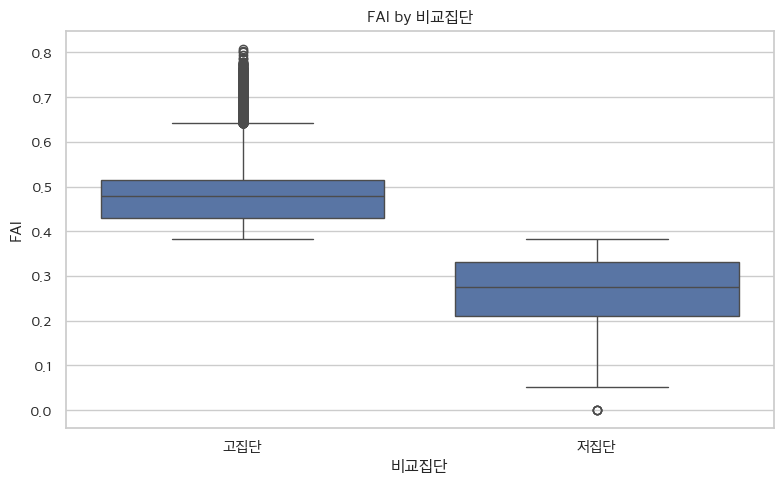

### 히스토그램

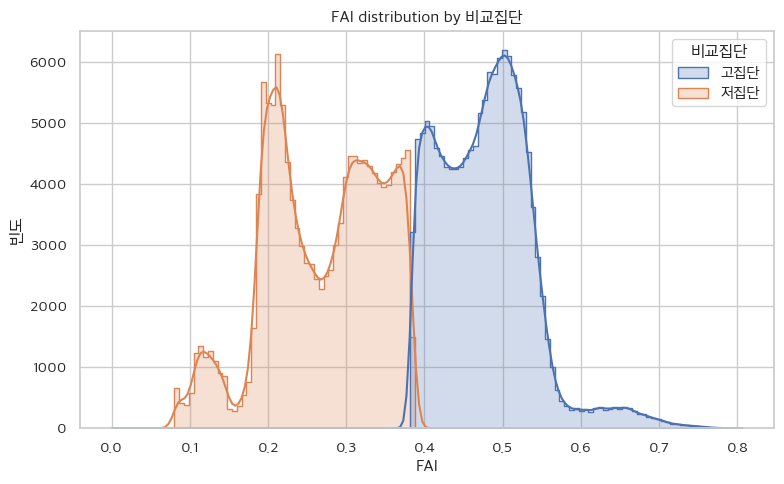

## 2. 수익성(FPI) 검정: 스타+알짜 vs 잠재+일반

### 비교집단 구성표

보완고객군,비교집단,스타(Star),알짜(Cash Cow),잠재(Potential),일반(Standard)
0,고집단,85662,56918,0,0
1,저집단,0,0,56918,85662


### 비교집단 구성비율표(%)

보완고객군,비교집단,스타(Star),알짜(Cash Cow),잠재(Potential),일반(Standard)
0,고집단,60.08,39.92,0.00,0.00
1,저집단,0.00,0.00,39.92,60.08


...

### 정규성 검정

,비교집단,Shapiro_p
0,고집단,4.514820e-54
1,저집단,7.271449e-83


### 검정 결과

,변수,고집단,저집단,검정방법,Levene_p,통계량,p_value,p_value_표시,결론
0,FPI,스타(Star) + 알짜(Cash Cow),잠재(Potential) + 일반(Standard),Mann-Whitney U,< 0.001,2.032906e+10,< 0.001,< 0.001,H0 기각 (차이 있음)


### 박스플롯

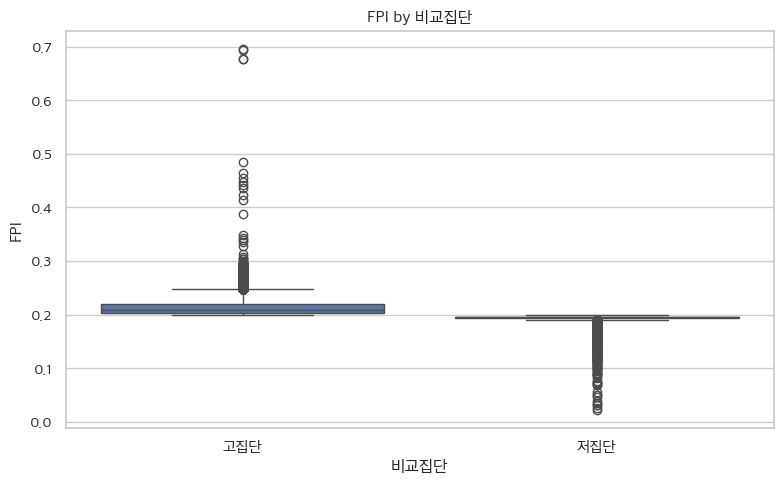

### 히스토그램

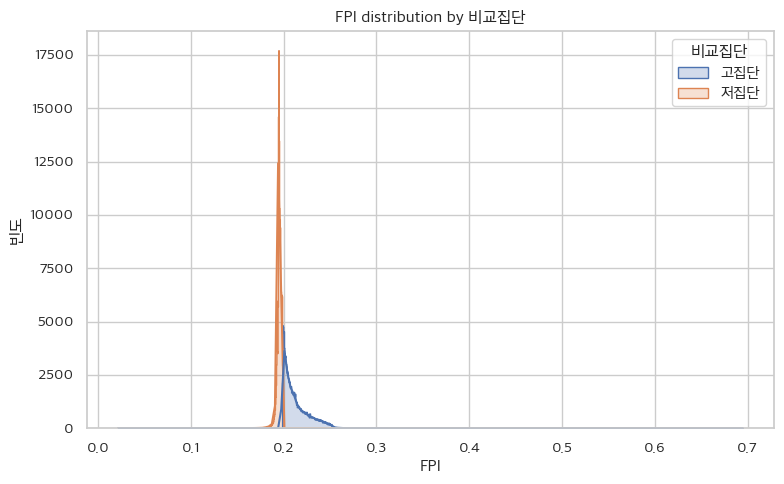

In [55]:
# =========================
# 연구질문 1 추가 검정: 의도한 고집단 vs 저집단 비교
# =========================
# 비교 전제:
# - 활동성(FAI)은 활동성 고/저 축으로 비교
#   -> 고집단: 스타 + 잠재 / 저집단: 알짜 + 일반
# - 수익성(FPI)은 수익성 고/저 축으로 비교
#   -> 고집단: 스타 + 알짜 / 저집단: 잠재 + 일반

from IPython.display import display, Markdown


df = analysis_df2.copy()

if '등급' in df.columns and '보완고객군' not in df.columns:
    df = df.rename(columns={'등급': '보완고객군'})

existing_grade_order = ['최우수', '우수', '일반']
supp_group_order = ['스타(Star)', '알짜(Cash Cow)', '잠재(Potential)', '일반(Standard)']

if '법인_고객등급' in df.columns:
    df['법인_고객등급'] = pd.Categorical(
        df['법인_고객등급'],
        categories=existing_grade_order,
        ordered=True
        )

if '보완고객군' in df.columns:
    existing_vals = [x for x in supp_group_order if x in df['보완고객군'].dropna().unique()]
    if existing_vals:
        df['보완고객군'] = pd.Categorical(
            df['보완고객군'],
            categories=existing_vals,
            ordered=True
        )
# -------------------------
# 기본 설정 / 보조 함수
# -------------------------
if "alpha" not in globals():
    alpha = 0.05

if "df" not in globals():
    raise NameError("df가 정의되어 있지 않습니다. 이전 셀에서 데이터프레임(df)을 먼저 생성하세요.")

if "보완고객군" not in df.columns:
    raise KeyError("df에 '보완고객군' 컬럼이 없습니다.")

def pretty_p_value(p):
    if pd.isna(p):
        return "NaN"
    if p < 0.001:
        return "< 0.001"
    return f"{p:.4f}"

def style_table(x):
    # 기존에 style_table 함수가 있으면 그걸 사용
    return x

# -------------------------
# 고집단 vs 저집단 비교 함수
# -------------------------
def compare_high_low_group(data, score_col, high_groups, low_groups, alpha=0.05):
    required_cols = ["보완고객군", score_col]
    for col in required_cols:
        if col not in data.columns:
            raise KeyError(f"data에 '{col}' 컬럼이 없습니다.")

    tmp = data[["보완고객군", score_col]].dropna().copy()
    tmp = tmp[tmp["보완고객군"].isin(high_groups + low_groups)].copy()

    if tmp.empty:
        raise ValueError(f"{score_col}에 대해 선택된 고/저집단 데이터가 없습니다.")

    tmp["비교집단"] = np.where(tmp["보완고객군"].isin(high_groups), "고집단", "저집단")
    tmp["비교집단"] = pd.Categorical(
        tmp["비교집단"],
        categories=["고집단", "저집단"],
        ordered=True
    )

    composition = pd.crosstab(tmp["비교집단"], tmp["보완고객군"])
    composition_pct = pd.crosstab(
        tmp["비교집단"],
        tmp["보완고객군"],
        normalize="index"
    ) * 100

    high = tmp.loc[tmp["비교집단"] == "고집단", score_col].dropna().values
    low = tmp.loc[tmp["비교집단"] == "저집단", score_col].dropna().values

    if len(high) < 2 or len(low) < 2:
        raise ValueError(f"{score_col}에 대해 고집단 또는 저집단 표본 수가 너무 적습니다.")

    desc = (
        tmp.groupby("비교집단", observed=False)[score_col]
        .agg(
            count="count",
            mean="mean",
            median="median",
            std="std",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
            min="min",
            max="max"
        )
        .reset_index()
    )

    # 등분산성 검정
    try:
        _, levene_p = stats.levene(high, low, center="median")
    except Exception:
        levene_p = np.nan

    # 샤피로는 너무 큰 표본에서 민감하므로 샘플 제한
    rng = np.random.default_rng(42)
    high_sample = high if len(high) <= 5000 else rng.choice(high, 5000, replace=False)
    low_sample = low if len(low) <= 5000 else rng.choice(low, 5000, replace=False)

    shapiro_rows = []
    if len(high_sample) >= 3:
        _, p_high = stats.shapiro(high_sample)
        shapiro_rows.append({"비교집단": "고집단", "Shapiro_p": p_high})
    if len(low_sample) >= 3:
        _, p_low = stats.shapiro(low_sample)
        shapiro_rows.append({"비교집단": "저집단", "Shapiro_p": p_low})

    shapiro_df = pd.DataFrame(shapiro_rows)

    roughly_normal = False
    if not shapiro_df.empty:
        roughly_normal = (shapiro_df["Shapiro_p"] >= alpha).all()

    # 검정 선택
    if roughly_normal:
        if pd.notna(levene_p) and levene_p >= alpha:
            test_name = "Independent t-test"
            stat, p = stats.ttest_ind(high, low, equal_var=True, nan_policy="omit")
        else:
            test_name = "Welch's t-test"
            stat, p = stats.ttest_ind(high, low, equal_var=False, nan_policy="omit")
    else:
        test_name = "Mann-Whitney U"
        stat, p = stats.mannwhitneyu(high, low, alternative="two-sided")

    summary = pd.DataFrame([{
        "변수": score_col,
        "고집단": " + ".join(high_groups),
        "저집단": " + ".join(low_groups),
        "검정방법": test_name,
        "Levene_p": levene_p,
        "통계량": stat,
        "p_value": p,
        "p_value_표시": pretty_p_value(p),
        "결론": "H0 기각 (차이 있음)" if p < alpha else "H0 채택 (차이 없음)"
    }])

    return {
        "원자료": tmp,
        "구성표": composition,
        "구성비율표": composition_pct.round(2),
        "기술통계": desc,
        "정규성": shapiro_df,
        "검정요약": summary
    }

# -------------------------
# 연구질문 1 검정 실행
# -------------------------

# 1) 활동성(FAI) 검정: 스타+잠재 vs 알짜+일반
rq1_fai = compare_high_low_group(
    data=df,
    score_col="FAI",
    high_groups=["스타(Star)", "잠재(Potential)"],
    low_groups=["알짜(Cash Cow)", "일반(Standard)"],
    alpha=alpha
)

# 2) 수익성(FPI) 검정: 스타+알짜 vs 잠재+일반
rq1_fpi = compare_high_low_group(
    data=df,
    score_col="FPI",
    high_groups=["스타(Star)", "알짜(Cash Cow)"],
    low_groups=["잠재(Potential)", "일반(Standard)"],
    alpha=alpha
)

# -------------------------
# 결과 출력 함수
# -------------------------
def show_rq1_result(result, score_label, title_text):
    display(Markdown(title_text))
    display(Markdown("### 비교집단 구성표"))
    display(style_table(result["구성표"].reset_index()))

    display(Markdown("### 비교집단 구성비율표(%)"))
    display(style_table(result["구성비율표"].reset_index()))

    display(Markdown("### 기술통계"))
    display(style_table(result["기술통계"]))

    display(Markdown("### 정규성 검정"))
    if not result["정규성"].empty:
        display(style_table(result["정규성"]))
    else:
        display(Markdown("- 정규성 검정을 위한 표본이 부족하거나 계산되지 않았습니다."))

    display(Markdown("### 검정 결과"))
    summary_df = result["검정요약"].copy()
    summary_df["Levene_p"] = summary_df["Levene_p"].apply(
        lambda x: pretty_p_value(x) if pd.notna(x) else "NaN"
    )
    summary_df["통계량"] = summary_df["통계량"].round(4)
    summary_df["p_value"] = summary_df["p_value"].apply(pretty_p_value)

    display(style_table(
        summary_df[[
            "변수", "고집단", "저집단", "검정방법",
            "Levene_p", "통계량", "p_value", "p_value_표시", "결론"
        ]]
    ))

    plot_data = result["원자료"].copy()

    display(Markdown("### 박스플롯"))
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=plot_data, x="비교집단", y=score_label)
    plt.title(f"{score_label} by 비교집단")
    plt.xlabel("비교집단")
    plt.ylabel(score_label)
    plt.tight_layout()
    plt.show()

    display(Markdown("### 히스토그램"))
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=plot_data,
        x=score_label,
        hue="비교집단",
        kde=True,
        element="step"
    )
    plt.title(f"{score_label} distribution by 비교집단")
    plt.xlabel(score_label)
    plt.ylabel("빈도")
    plt.tight_layout()
    plt.show()

# -------------------------
# 결과 출력
# -------------------------
display(Markdown("# 연구질문 1 추가 검정: 의도한 고집단 vs 저집단 비교"))
display(Markdown(
    "4집단 전체 분포 비교와 별도로, 보완고객군이 활동성과 수익성의 고/저 집단을 "
    "의도한 대로 구분하는지 직접 검정한 결과입니다."
))

show_rq1_result(
    rq1_fai,
    "FAI",
    "## 1. 활동성(FAI) 검정: 스타+잠재 vs 알짜+일반"
)

show_rq1_result(
    rq1_fpi,
    "FPI",
    "## 2. 수익성(FPI) 검정: 스타+알짜 vs 잠재+일반"
)

#### 가설 4~5 결과 해석

- 가설 4 결과: 고집단의 평균 FAI는 `0.4491`, 저집단의 평균 FAI는 `0.2145`였고, `Mann-Whitney U` 검정 p-value는 `0.001 미만`으로 나타났습니다.
- 가설 5 결과: 고집단의 평균 FPI는 `0.2140`, 저집단의 평균 FPI는 `0.1971`이었고, 역시 p-value는 `0.001 미만`이었습니다.

즉 활동성 축과 수익성 축 모두 고·저집단을 통계적으로 유의하게 구분했기 때문에, 새 사분면의 축 구성은 실제 데이터의 차이를 반영하는 타당한 분류 기준이라고 해석할 수 있습니다.


# 가설(창은)



### 가설 6. 알짜(Cash Cow)는 스타(Star)보다 자산대비수익률이 더 높은가?

- 귀무가설(H0): 알짜와 스타의 자산대비수익률 차이는 없다.
- 대립가설(H1): 알짜의 자산대비수익률이 스타보다 더 높다.

이 가설은 규모가 큰 전통적 우량고객(스타) 외에도, 더 높은 수익 효율을 내는 실속형 고객군(알짜)이 존재하는지 검증하기 위해 수행합니다.
등분산 여부를 먼저 확인한 뒤, 비모수 `Mann-Whitney U 검정`(단측)을 사용합니다.


In [56]:
# H0 : 알짜등급과 스타등급 간 자산대비수익률의 차이가 없다.
# H1 : 알짜등급이 스타등급보다 자산대비수익률이 더 클 것이다.

# 설정 이유: 은행의 전통적인 우량 고객인 '스타' 등급은 상대적으로 큰 자산 규모를 바탕으로 수익을 창출한다. 하지만 iM뱅크의 경영가치 달성을 위해서는 자산 규모는 작더라도 수익 기여도가 높은 '강소 중소기업(알짜)'의 가치를 재발견 및 투자 증대를 해야 한다. 이에 자본 효율성을 나타내는 자산대비수익률을 비교하여, 규모가 작은 기업에 대한 금융 지원 및 투자 확대가 은행의 전체 수익 지지력(Profitability)에 기여할 수 있음을 입증하고자 한다.

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 등급 이름 정의
grade_star = '스타(Star)'
grade_cashcow = '알짜(Cash Cow)'

# 2. 데이터 클리닝
analysis_df2.replace([np.inf, -np.inf], np.nan, inplace=True)
clean_df = analysis_df2.dropna(subset=['자산대비수익률(%)', '총자산', 'FAI', '등급'])

# 3. 데이터 그룹 추출
star_group = clean_df[clean_df['등급'] == grade_star]['자산대비수익률(%)']
cashcow_group = clean_df[clean_df['등급'] == grade_cashcow]['자산대비수익률(%)']

# 4. 기초 통계량 확인 (규모 및 활동성 차이 확인용)
print("### 등급별 기초 통계량 ->  ###")
summary = clean_df[clean_df['등급'].isin([grade_star, grade_cashcow])].groupby('등급')[['총자산', 'FAI', '자산대비수익률(%)']].mean()
print(summary)
print("\n")

# 5. 등분산 검정
levene_stat, levene_p = stats.levene(cashcow_group, star_group)

print("--- 등분산성 검정 결과 (스타 vs 알짜) ---")
print(f"levene: {levene_stat:.4f}")
print(f"levene_p: {levene_p:.4f}")

# 6. 맨-휘트니 U 검정 (비모수 검정) 수행
# alternative='greater'는 cashcow_group의 분포가 star_group보다 큰 쪽에 있는지 확인합니다.
u_stat, p_val_u = stats.mannwhitneyu(cashcow_group, star_group,alternative='greater')

print("--- 비모수 검정 결과 (Mann-Whitney U Test) ---")
print(f"U-statistic: {u_stat:.4f}")
print(f"P-value: {p_val_u:.4f}")

# 7. 결과 해석
alpha = 0.05
print("\n [비모수 검정 최종 해석] ")
if p_val_u < alpha:
    print(f"결과: p-value({p_val_u:.4f}) < {alpha} 이므로 귀무가설을 기각합니다.")
    print(f"해석: '{grade_cashcow}' 등급의 자산대비수익률 분포가 '{grade_star}' 등급보다 통계적으로 유의미하게 더 높은 위치에 있습니다.")
    print("결론: 이상치의 영향을 배제하더라도 알짜 기업의 수익 효율성이 스타 기업보다 우수함이 증명되었다.  \n  이를 통해 알짜기업의 투자를 늘리는 것이 단순히 경영가치 달성만을 위한 것이 아니라 iM뱅크의 수익 효율성도 높일 수 있다.")
else:
    print(f"결과: p-value({p_val_u:.4f}) >= {alpha} 이므로 귀무가설을 채택합니다.")
    print(f"해석: 두 등급 간 수익 효율성 분포의 차이가 통계적으로 유의미하지 않다.")

### 등급별 기초 통계량 ->  ###
                      총자산       FAI  자산대비수익률(%)
등급                                             
스타(Star)      1359.395399  0.490201    0.360234
알짜(Cash Cow)  1087.149398  0.286268    0.468259


--- 등분산성 검정 결과 (스타 vs 알짜) ---
levene: 12.0721
levene_p: 0.0005
--- 비모수 검정 결과 (Mann-Whitney U Test) ---
U-statistic: 3275821406.0000
P-value: 0.0000

 [비모수 검정 최종 해석] 
결과: p-value(0.0000) < 0.05 이므로 귀무가설을 기각합니다.
해석: '알짜(Cash Cow)' 등급의 자산대비수익률 분포가 '스타(Star)' 등급보다 통계적으로 유의미하게 더 높은 위치에 있습니다.
결론: 이상치의 영향을 배제하더라도 알짜 기업의 수익 효율성이 스타 기업보다 우수함이 증명되었다.  
  이를 통해 알짜기업의 투자를 늘리는 것이 단순히 경영가치 달성만을 위한 것이 아니라 iM뱅크의 수익 효율성도 높일 수 있다.


#### 가설 6 결과 해석

- 스타 평균 총자산: `1276.999`
- 알짜 평균 총자산: `1071.498`
- 스타 평균 자산대비수익률: `0.3760`
- 알짜 평균 자산대비수익률: `0.6534`
- Levene p-value: `0.0001`
- Mann-Whitney U 검정 p-value: `0.001 미만`

결과적으로 알짜는 스타보다 규모는 작지만 자산대비수익률은 더 높게 나타났습니다. 즉 알짜는 단순 중간 고객이 아니라, 은행 입장에서 높은 효율을 내는 실속형 우량고객으로 해석할 수 있습니다.


In [57]:
analysis_df2['총자산'].describe()

count    285160.000000
mean        707.149901
std         946.634615
min           0.010000
25%          91.600000
50%         311.000000
75%         919.725000
max       43400.000000
Name: 총자산, dtype: float64

# 가설(주희)

### 가설 7. 알짜(Cash Cow) 그룹 내에서도 기존 등급별 수익성 차이가 존재하는가?

- 귀무가설(H0): 알짜 그룹 내 기존 등급별 FPI 중앙값 차이는 없다.
- 대립가설(H1): 알짜 그룹 내 기존 등급별 FPI 중앙값 차이는 있다.

이 가설은 알짜 그룹이 기존 등급과 무관하게 동일한 고객군인지, 혹은 내부적으로도 수익성 차이가 존재하는지 확인하기 위해 수행합니다.
`Kruskal-Wallis 검정`과 `Dunn 사후검정`을 사용합니다.

### 가설 8. 알짜(Cash Cow) 그룹 내 기존 하위등급 고객은 더 높은 활동 대비 수익 효율을 보이는가?

- 귀무가설(H0): 알짜 그룹 내 기존 등급별 활동 수익 밀도 차이는 없거나 기존 등급 순서와 일치한다.
- 대립가설(H1): 기존 하위등급 고객이 더 높은 활동 대비 수익 효율을 보인다.

이 가설은 기존 등급이 낮더라도 실제 효율은 더 높은 숨은 우량고객이 존재하는지 확인하기 위해 수행합니다.
지표는 `총수익 / 총채널거래건수`이고, `Kruskal-Wallis 검정`과 `Dunn 사후검정`을 사용합니다.

### 가설 9. 거래건수 보정 후에도 일반 알짜의 효율 우위는 유지되는가?

- 귀무가설(H0): 보정 활동 수익 밀도는 기존 등급 순서와 차이가 없거나 비례한다.
- 대립가설(H1): 보정 후에도 일반 알짜가 우수 알짜보다 높은 효율을 보인다.

이 가설은 거래건수 0 문제를 보정한 뒤에도 숨은 우량고객 가설이 유지되는지 확인하기 위해 수행합니다.
지표는 `총수익 / (총채널거래건수 + 1)`이며 동일하게 `Kruskal-Wallis 검정`과 `Dunn 사후검정`을 사용합니다.


In [58]:
# ### 4. 가설 검정 STEP 3: 기존 등급별 '알짜(Cash Cow)'의 정체성 발굴
# 기존 '일반' 등급에 숨어있는 '알짜'는 진짜 우량한가?
# 분석 내용: 기존 등급별 '알짜' 세그먼트의 FPI 및 효율성 비교.

# #### 4-1. '알짜(Cash Cow) 그룹의 수익 효율 일관성 검증
# 기존 등급(안정성)에 상관없이, 우리가 '알짜'로 뽑은 애들은 다 수익성이 끝내준다에 대한 이야기

# 귀무가설(H0):
# '알짜' 그룹 내에서 기존 고객등급(최우수/우수/일반)에 따른 수익성(FPI) 중앙값 차이는 유의미하지 않을 것이다. (즉, '알짜' 그룹은 기존 등급과 무관하게 고른 수익 효율을 보인다.)

# 대립가설(H1):
# '알짜' 그룹 내에서도 기존 등급에 따라 수익성(FPI) 중앙값은 통계적으로 유의미한 차이가 있을 것이다.

from scipy.stats import levene

# 1. '알짜' 등급만 필터링
alzza_df = analysis_df2[analysis_df2['등급'] == '알짜(Cash Cow)']

# 2. 알짜 내 기존 등급(최우수, 우수, 일반)별 FPI 데이터 추출
alzza_fpi_groups = [group['FPI'].values for name, group in alzza_df.groupby('법인_고객등급')]

# 3. Levene 검정 수행 (중앙값 기준)
stat_levene, p_levene_alzza = levene(*alzza_fpi_groups, center='median')

print(f"알짜 그룹 내 기존 등급별 FPI 등분산성 p-value: {p_levene_alzza}")

from scipy.stats import kruskal
# 알짜 내에서 기존 등급별 FPI 분포 확인
stat_fpi, p_val_fpi = kruskal(*alzza_fpi_groups)

print(f"알짜 그룹 내 기존 등급별 FPI 차이 p-value: {p_val_fpi}")

# 등급별 FPI 중앙값 확인
alzza_fpi_median = alzza_df.groupby('법인_고객등급')['FPI'].median()
alzza_fpi_mean = alzza_df.groupby('법인_고객등급')['FPI'].mean()
print("\n=== 알짜 내 기존 등급별 FPI 중앙값 ===")
print(alzza_fpi_median)
print("\n=== 알짜 내 기존 등급별 FPI 평균 ===")
print(alzza_fpi_mean)

import scikit_posthocs as sp

# 알짜 등급 내 기존 등급 간 FPI 사후 분석
posthoc_alzza = sp.posthoc_dunn(alzza_df, val_col='FPI', group_col='법인_고객등급', p_adjust='bonferroni')

print("=== [알짜 내] 기존 등급 간 FPI 사후 분석 결과 ===")
print(posthoc_alzza)

#### 4-2. 알짜(Cash Cow) 그룹 내 기존 등급별 '활동 수익 밀도' 역전 현상 검증
#기존 등급이 낮을수록 오히려 적은 활동으로 큰 수익을 내는 '진짜 알짜'일 수 있다

#가설검정 :

#귀무가설(H0): '알짜' 그룹 내에서 기존 등급(최우수/우수/일반)에 따른 '건당 수익성(활동 대비 수익)' 중앙값 차이는 존재하지 않거나 기존 등급 순서와 일치할 것이다.

#대립가설(H1): 기존 등급이 낮음에도 불구하고 '알짜'로 분류된 집단이 기존 상위 등급 대비 **유의미하게 높은 '건당 수익성'**을 보일 것이다. (즉, 수익 효율의 역전 현상이 존재한다.)

# 1. 활동 수익 밀도 지표 생성
alzza_df = analysis_df2[analysis_df2['등급'] == '알짜(Cash Cow)'].copy()
alzza_df['활동 수익 밀도'] = alzza_df['총수익'] / alzza_df['총채널거래건수']

# 2. 등분산성 및 Kruskal-Wallis
from scipy.stats import levene, kruskal
import scikit_posthocs as sp

groups = [group['활동 수익 밀도'].values for name, group in alzza_df.groupby('법인_고객등급')]
print(f"활동 수익 밀도 Kruskal p-value: {kruskal(*groups)[1]}")

# 3. 사후분석
posthoc_eff = sp.posthoc_dunn(alzza_df, val_col='활동 수익 밀도', group_col='법인_고객등급', p_adjust='bonferroni')
print("\n=== [알짜 내] 기존 등급별 활동 수익 밀도 사후분석 ===")
print(posthoc_eff)

# 4. 중앙값 확인
print("\n=== 활동 수익 밀도 중앙값 ===")
print(alzza_df.groupby('법인_고객등급')['활동 수익 밀도'].median())

print(f'Kruskal-Wallis 검정 결과, 등급 간 활동 수익 밀도 차이는 통계적으로 매우 유의미함 (p < 0.001)')
print("\n 사후 분석(Dunn's Test) 결과, 모든 기존 등급 간 '건당 수익 효율성'은 통계적으로 유의미한 차이를 보였음 (p < 0.001)")

# 일반 등급 알짜들 중에서 거래 건수가 0인 사람이 몇 명이나 되는지 확인
zero_count = len(alzza_df[(alzza_df['법인_고객등급'] == '일반') & (alzza_df['총채널거래건수'] == 0)])
total_general_alzza = len(alzza_df[alzza_df['법인_고객등급'] == '일반'])

print(f"일반 등급 알짜 {total_general_alzza}명 중 거래건수 0인 사람: {zero_count}명")



#### 4-3. 알짜(Cash Cow) 그룹 내 기존 등급별 '실질 운영 효율(보정 수익 밀도)' 역전 현상 검증

# 덩치(자산)에 가려졌던 실질적인 가성비(Efficiency)의 진실을 밝히고자.

# 가설검정 :

# 귀무가설(H0): '알짜' 그룹 내에서 기존 등급(최우수/우수/일반)에 따른 '보정 건당 수익성(수치 보정 후 효율)' 중앙값 차이는 없거나 기존 등급 순서와 비례할 것이다.

# 대립가설(H1): '보정' 후의 데이터 분석 결과, 기존 하위 등급(일반) 기업이 상위 등급 대비 **유의미하게 높은 '보정 건당 수익성'**을 보일 것이다. (즉, 보정 후에도 효율 역전 현상이 견고함을 입증)

from scipy.stats import kruskal

# 1. 분모에 1을 더해서 보정된 지표 생성 (Smoothing)
alzza_df['보정_활동 수익 밀도'] = alzza_df['총수익'] / (alzza_df['총채널거래건수'] + 1)

# 2. kruskal분석
stat, p_total = kruskal(*[group['보정_활동 수익 밀도'].values for name, group in alzza_df.groupby('법인_고객등급')])
print(f"전체 Kruskal p-value: {p_total}")

# 3. 사후분석 (Dunn's Test)
import scikit_posthocs as sp
posthoc_safe = sp.posthoc_dunn(alzza_df, val_col='보정_활동 수익 밀도', group_col='법인_고객등급', p_adjust='bonferroni')

print("=== [보정 버전] 알짜 내 기존 등급별 활동 수익 밀도 사후분석 ===")
print(posthoc_safe)

# 4. 중앙값 확인
print("\n=== 보정된 활동 수익 밀도 중앙값 ===")
print(alzza_df.groupby('법인_고객등급')['보정_활동 수익 밀도'].median())

알짜 그룹 내 기존 등급별 FPI 등분산성 p-value: 0.0
알짜 그룹 내 기존 등급별 FPI 차이 p-value: 0.0

=== 알짜 내 기존 등급별 FPI 중앙값 ===
법인_고객등급
우수     0.203351
일반     0.202946
최우수    0.215650
Name: FPI, dtype: float64

=== 알짜 내 기존 등급별 FPI 평균 ===
법인_고객등급
우수     0.206526
일반     0.207354
최우수    0.219102
Name: FPI, dtype: float64
=== [알짜 내] 기존 등급 간 FPI 사후 분석 결과 ===
      우수   일반  최우수
우수   1.0  1.0  0.0
일반   1.0  1.0  0.0
최우수  0.0  0.0  1.0
활동 수익 밀도 Kruskal p-value: 4.4787309111096675e-57

=== [알짜 내] 기존 등급별 활동 수익 밀도 사후분석 ===
               우수            일반           최우수
우수   1.000000e+00  4.755569e-41  1.246423e-39
일반   4.755569e-41  1.000000e+00  6.359404e-02
최우수  1.246423e-39  6.359404e-02  1.000000e+00

=== 활동 수익 밀도 중앙값 ===
법인_고객등급
우수     3.592883
일반          inf
최우수    7.442512
Name: 활동 수익 밀도, dtype: float64
Kruskal-Wallis 검정 결과, 등급 간 활동 수익 밀도 차이는 통계적으로 매우 유의미함 (p < 0.001)

 사후 분석(Dunn's Test) 결과, 모든 기존 등급 간 '건당 수익 효율성'은 통계적으로 유의미한 차이를 보였음 (p < 0.001)
일반 등급 알짜 11590명 중 거래건수 0인 사람: 6202명
전체 Kruskal p-value: 0.0
=== [보정 버전

#### 가설 7~9 결과 해석

- 가설 7 결과: 알짜 그룹 내 기존 등급별 FPI 차이는 전체적으로 `p-value 0.001 미만`으로 유의했습니다. 다만 FPI 중앙값은 우수 `0.2048`, 일반 `0.2045`, 최우수 `0.2162`였고, 사후검정에서 `우수 vs 일반`은 `p=0.3168`로 유의하지 않았습니다.
- 가설 8 결과: 활동 수익 밀도에 대한 `Kruskal-Wallis` 검정 p-value는 `9.81e-52`였고, 사후분석에서는 모든 기존 등급 쌍이 유의했습니다. 다만 일반 알짜 `11,074명` 중 거래건수 0인 고객이 `6,012명` 있어 원지표 해석에는 보정이 필요했습니다.
- 가설 9 결과: 보정 활동 수익 밀도 중앙값은 우수 `1.2234`, 일반 `1.3473`, 최우수 `2.1020`이었고, 전체 p-value는 `0.001 미만`이었으며 모든 등급 쌍이 유의했습니다.

즉 일반 알짜는 우수 알짜와 수익성 차이가 유의하지 않았고, 거래건수 보정 후에는 오히려 우수 알짜보다 더 높은 효율을 보였습니다. 이는 기존 등급만으로는 포착되지 않는 숨은 고효율 고객이 실제로 존재한다는 근거가 됩니다.


-------------------------------

# 가설( 상면 ) 

In [59]:
# # =========================
# # [셀 3] 세그먼트 간 차이 검정 실행
# # =========================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from matplotlib.patches import Patch
# from scipy import stats

# # -------------------------
# # 사전 점검
# # -------------------------
# required_vars = [
#     "df2", "seg_dict", "segment_order", "analysis_df2",
#     "eta_squared", "interpret_eta", "cramers_v", "interpret_cramers_v"
# ]

# segment_order= ['스타(Star)', '알짜(Cash Cow)', '잠재(Potential)', '일반(Standard)']

# def eta_squared(groups):
#     all_data = np.concatenate(groups)
#     grand_mean = all_data.mean()
#     ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
#     ss_total = sum((x - grand_mean) ** 2 for x in all_data)
#     return ss_between / ss_total if ss_total != 0 else 0

# def interpret_eta(eta):
#     if eta < 0.01:
#         return '효과없음'
#     elif eta < 0.06:
#         return 'Low'
#     elif eta < 0.14:
#         return 'Medium'
#     else:
#         return 'High'
    
#     def interpret_cramers_v(v):
#         if v < 0.10:
#             return 'Negligible'
#         elif v < 0.30:
#             return 'Low'
#         elif v < 0.50:
#             return 'Medium'
#         else:
#             return 'High'
        
# analysis_df2['세그먼트'] = analysis_df2['등급']
# seg_dict = {
#     s: analysis_df2[analysis_df2['세그먼트'] == s].copy()
#     for s in segment_order
#     }
# for var in required_vars:
#     if var not in globals():
#         raise NameError(f"'{var}' 가 정의되어 있지 않습니다. 이전 셀을 먼저 실행하세요.")

# # -------------------------
# # 컬럼명 보정
# # -------------------------
# asset_return_col = "자산대비수익률"
# if asset_return_col not in df2.columns:
#     if "자산대비수익률(%)" in df2.columns:
#         asset_return_col = "자산대비수익률(%)"
#     else:
#         raise KeyError("자산대비수익률 컬럼이 없습니다. 실제 컬럼명을 확인하세요.")

# if "세그먼트" not in analysis_df2.columns:
#     raise KeyError("analysis_df2에 '세그먼트' 컬럼이 없습니다.")

# if "외환이용" not in analysis_df2.columns:
#     raise KeyError("analysis_df2에 '외환이용' 컬럼이 없습니다.")

# # -------------------------
# # ANOVA / 카이제곱 검정
# # -------------------------
# anova_specs = [
#     ("총채널거래건수", "총채널거래건수", "거래 건수"),
#     ("상품다양성개수", "상품다양성개수", "상품 종류 수"),
#     ("예대마진", "예대마진", "만원"),
#     (asset_return_col, "자산대비수익률", "%")
# ]

# results = []

# # ANOVA
# for col, label, unit in anova_specs:
#     grp_data = []
#     for s in segment_order:
#         if col not in seg_dict[s].columns:
#             raise KeyError(f"seg_dict['{s}']에 '{col}' 컬럼이 없습니다.")
#         vals = seg_dict[s][col].dropna().values
#         grp_data.append(vals)

#     if any(len(g) == 0 for g in grp_data):
#         raise ValueError(f"'{col}' 변수에 대해 비어 있는 세그먼트 그룹이 있습니다.")

#     f_stat, p_val = stats.f_oneway(*grp_data)
#     eta = eta_squared(grp_data)

#     k = len(grp_data)
#     n_total = sum(len(g) for g in grp_data)
#     df_between = k - 1
#     df_within = n_total - k

#     results.append({
#         "변수": label,
#         "검정": "ANOVA",
#         "통계량": float(f_stat),
#         "p-value": float(p_val),
#         "자유도": f"({df_between}, {df_within})",
#         "효과크기값": float(eta),
#         "효과크기": interpret_eta(eta),
#         "유의성": "★ 유의" if p_val < 0.05 else "비유의"
#     })

# # 카이제곱 검정
# contingency = pd.crosstab(analysis_df2["세그먼트"], analysis_df2["외환이용"])
# chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
# cv = cramers_v(contingency)

# results.append({
#     "변수": "외환이용",
#     "검정": "카이제곱 검정",
#     "통계량": float(chi2),
#     "p-value": float(p_val),
#     "자유도": int(dof),
#     "효과크기값": float(cv),
#     "효과크기": interpret_cramers_v(cv),
#     "유의성": "★ 유의" if p_val < 0.05 else "비유의"
# })

# # -------------------------
# # 결과 표 보기
# # -------------------------
# results_df = pd.DataFrame(results).copy()

# results_df_display = results_df.copy()
# results_df_display["통계량"] = results_df_display["통계량"].round(4)
# results_df_display["p-value"] = results_df_display["p-value"].apply(lambda x: f"{x:.6e}")
# results_df_display["효과크기값"] = results_df_display["효과크기값"].round(4)

# results_df_display = results_df_display[
#     ["변수", "검정", "통계량", "p-value", "자유도", "효과크기값", "효과크기", "유의성"]
# ]

# def highlight_sig(val):
#     if val == "★ 유의":
#         return "color: red; font-weight: bold;"
#     return ""

# def highlight_effect(val):
#     if val == "High":
#         return "color: #1D9E75; font-weight: bold;"
#     elif val == "Medium":
#         return "color: #F2A623; font-weight: bold;"
#     elif val == "Low":
#         return "color: #378ADD;"
#     else:
#         return "color: gray;"

# display(
#     results_df_display.style
#     .applymap(highlight_sig, subset=["유의성"])
#     .applymap(highlight_effect, subset=["효과크기"])
#     .set_properties(**{"text-align": "center"})
#     .set_table_styles([
#         {
#             "selector": "th",
#             "props": [
#                 ("background-color", "#F1EFE8"),
#                 ("color", "#2C2C2A"),
#                 ("font-weight", "bold"),
#                 ("text-align", "center")
#             ]
#         },
#         {
#             "selector": "td",
#             "props": [("padding", "6px 10px")]
#         }
#     ])
# )

# # =========================
# # [셀 4] 시각화 - 가독성 개선 버전
# # =========================

# C_BG = "#F8F7F4"
# C_CARD = "#FFFFFF"
# C_RED = "#E24B4A"
# C_TEXT = "#2C2C2A"
# C_SUB = "#5F5E5A"
# C_LINE = "#D3D1C7"

# if "segment_labels" not in globals():
#     segment_labels = ["스타", "알짜", "잠재", "일반"]

# if "segment_colors" not in globals():
#     segment_colors = ["#1D9E75", "#378ADD", "#F2A623", "#D3D1C7"]

# fig = plt.figure(figsize=(22, 15), facecolor=C_BG)
# fig.suptitle(
#     "세그먼트별 핵심 변수 차이 검정",
#     fontsize=17, fontweight="bold", y=0.99, color=C_TEXT
# )
# fig.text(
#     0.5, 0.965,
#     "스타 / 알짜 / 잠재 / 일반 세그먼트가 실제로 서로 다른 특성을 보이는지 확인",
#     ha="center", fontsize=10, color=C_SUB
# )

# gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

# manual_ylim = {
#     "자산대비수익률": (0, 8),
#     "자산대비수익률(%)": (0, 8)
# }

# def plot_anova(ax, col, label, unit, result_row):
#     ax.set_facecolor(C_CARD)

#     grp_data = [seg_dict[s][col].dropna().values for s in segment_order]

#     bp = ax.boxplot(
#         grp_data,
#         patch_artist=True,
#         vert=True,
#         widths=0.5,
#         showfliers=False,
#         medianprops=dict(color=C_TEXT, linewidth=2),
#         whiskerprops=dict(color="#9E9B90", linewidth=1.2),
#         capprops=dict(color="#9E9B90", linewidth=1.2)
#     )

#     for patch, color in zip(bp["boxes"], segment_colors):
#         patch.set_facecolor(color)
#         patch.set_alpha(0.6)

#     for j, (s, color) in enumerate(zip(segment_order, segment_colors)):
#         mean_val = seg_dict[s][col].mean()
#         ax.scatter(j + 1, mean_val, marker="D", color=color, s=45, zorder=5)
#         ax.text(
#             j + 1, mean_val, f" {mean_val:.2f}",
#             fontsize=8, color=color, fontweight="bold",
#             va="bottom", ha="left"
#         )

#     p = result_row["p-value"]
#     eta = result_row["효과크기값"]
#     eta_interp = result_row["효과크기"]
#     sig = result_row["유의성"]
#     df_text = result_row["자유도"]

#     info = (
#         f"F={result_row['통계량']:.2f}, p={p:.3e}, {sig}\n"
#         f"eta²={eta:.4f} ({eta_interp}), {df_text}"
#     )

#     ax.text(
#         0.5, 0.96, info,
#         transform=ax.transAxes,
#         ha="center", va="top",
#         fontsize=8.8,
#         color=C_RED if p < 0.05 else "#888780",
#         fontweight="bold",
#         bbox=dict(
#             boxstyle="round,pad=0.25",
#             facecolor="#F1EFE8",
#             edgecolor="#D3D1C7",
#             linewidth=0.8
#         )
#     )

#     ax.set_xticks(range(1, len(segment_order) + 1))
#     ax.set_xticklabels(segment_labels, fontsize=10, color=C_TEXT)
#     ax.set_title(f"{label} — ANOVA", fontsize=11, fontweight="bold", color=C_TEXT, pad=10)
#     ax.set_ylabel(unit, fontsize=9, color=C_SUB)

#     if col in manual_ylim:
#         ax.set_ylim(manual_ylim[col])

#     ax.spines[["top", "right"]].set_visible(False)
#     ax.spines[["left", "bottom"]].set_color(C_LINE)
#     ax.tick_params(labelsize=9, colors=C_SUB)
#     ax.grid(axis="y", color="#E6E3DA", linestyle="-", linewidth=0.7, alpha=0.8)
#     ax.set_axisbelow(True)

# def plot_chi(ax, result_row):
#     ax.set_facecolor(C_CARD)

#     fx_pct = (
#         analysis_df2.groupby("세그먼트")["외환이용"]
#         .mean() * 100
#     ).reindex(segment_order)

#     bars = ax.bar(
#         range(len(segment_order)),
#         fx_pct.values,
#         color=segment_colors,
#         alpha=0.8,
#         edgecolor="none",
#         width=0.55
#     )

#     for bar, v in zip(bars, fx_pct.values):
#         ax.text(
#             bar.get_x() + bar.get_width() / 2,
#             bar.get_height() + 0.15,
#             f"{v:.1f}%",
#             ha="center", fontsize=9.5,
#             color=C_TEXT, fontweight="bold"
#         )

#     p = result_row["p-value"]
#     cv = result_row["효과크기값"]
#     cv_interp = result_row["효과크기"]
#     sig = result_row["유의성"]
#     df_text = result_row["자유도"]

#     info = (
#         f"χ²={result_row['통계량']:.2f}, p={p:.3e}, {sig}\n"
#         f"Cramer's V={cv:.4f} ({cv_interp}), df={df_text}"
#     )

#     ax.text(
#         0.5, 0.96, info,
#         transform=ax.transAxes,
#         ha="center", va="top",
#         fontsize=8.8,
#         color=C_RED if p < 0.05 else "#888780",
#         fontweight="bold",
#         bbox=dict(
#             boxstyle="round,pad=0.25",
#             facecolor="#F1EFE8",
#             edgecolor="#D3D1C7",
#             linewidth=0.8
#         )
#     )

#     ax.set_xticks(range(len(segment_order)))
#     ax.set_xticklabels(segment_labels, fontsize=10, color=C_TEXT)
#     ax.set_title("외환이용 비율 — 카이제곱 검정", fontsize=11, fontweight="bold", color=C_TEXT, pad=10)
#     ax.set_ylabel("외환이용 비율 (%)", fontsize=9, color=C_SUB)
#     ax.spines[["top", "right"]].set_visible(False)
#     ax.spines[["left", "bottom"]].set_color(C_LINE)
#     ax.tick_params(labelsize=9, colors=C_SUB)
#     ax.grid(axis="y", color="#E6E3DA", linestyle="-", linewidth=0.7, alpha=0.8)
#     ax.set_axisbelow(True)

# plot_anova(
#     fig.add_subplot(gs[0, 0]),
#     "총채널거래건수", "총채널거래건수", "거래 건수",
#     results_df[results_df["변수"] == "총채널거래건수"].iloc[0]
# )

# plot_anova(
#     fig.add_subplot(gs[0, 1]),
#     "상품다양성개수", "상품다양성개수", "상품 종류 수",
#     results_df[results_df["변수"] == "상품다양성개수"].iloc[0]
# )

# plot_anova(
#     fig.add_subplot(gs[0, 2]),
#     "예대마진", "예대마진", "만원",
#     results_df[results_df["변수"] == "예대마진"].iloc[0]
# )

# plot_anova(
#     fig.add_subplot(gs[1, 0]),
#     asset_return_col, "자산대비수익률", "%",
#     results_df[results_df["변수"] == "자산대비수익률"].iloc[0]
# )

# plot_chi(
#     fig.add_subplot(gs[1, 1]),
#     results_df[results_df["변수"] == "외환이용"].iloc[0]
# )

# legend_elements = [
#     Patch(facecolor=c, alpha=0.8, label=l)
#     for c, l in zip(segment_colors, segment_labels)
# ]

# fig.legend(
#     handles=legend_elements,
#     loc="upper right",
#     bbox_to_anchor=(0.99, 0.97),
#     framealpha=0.95,
#     labelcolor="#3D3D3A",
#     fontsize=9,
#     edgecolor="#D3D1C7"
# )

# plt.savefig(
#     "segment_validation_anova_readable.png",
#     dpi=150,
#     bbox_inches="tight",
#     facecolor=C_BG
# )
# plt.show()

# # =========================
# # [셀 5] 업종별 세그먼트 분포 시각화
# # =========================

# import matplotlib.pyplot as plt

# plt.rcParams["font.family"] = "Malgun Gothic"
# plt.rcParams["axes.unicode_minus"] = False

# segment_labels = ["스타", "알짜", "잠재", "일반"]
# segment_colors = ["#1D9E75", "#378ADD", "#F2A623", "#D3D1C7"]

# plot_df = ct_row_pct.copy()
# plot_df.columns = segment_labels

# ax = plot_df.plot(
#     kind="bar",
#     stacked=True,
#     figsize=(14, 7),
#     color=segment_colors,
#     edgecolor="none"
# )

# plt.title("업종별 세그먼트 분포(비율)", fontsize=14, fontweight="bold")
# plt.xlabel("업종", fontsize=10)
# plt.ylabel("비율(%)", fontsize=10)
# plt.legend(title="세그먼트", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()